In [1]:
# ============================================================
# 1. Setup for spatial-accuracy-only control GLM
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from IPython.display import display

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
DATA_DIR = PROJECT_ROOT / "data"
BIDS_DIR = DATA_DIR / "bids_ackbar"
FMRIPREP_DIR = DATA_DIR / "fmriprep_output"

PRIMARY_ANALYSIS_NAME = "memory_quality_post_viewing_parametric"
PRIMARY_OUT_DIR = DATA_DIR / "processed" / "glm" / PRIMARY_ANALYSIS_NAME
PRIMARY_TABLE_DIR = PRIMARY_OUT_DIR / "tables"

CONTROL_ANALYSIS_NAME = "spatial_accuracy_only_post_viewing_parametric"
CONTROL_OUT_DIR = DATA_DIR / "processed" / "glm" / CONTROL_ANALYSIS_NAME
CONTROL_EVENTS_DIR = DATA_DIR / "preprocessed" / "relabeled_events_spatial_accuracy_only"
CONTROL_FIG_DIR = CONTROL_OUT_DIR / "figures"
CONTROL_TABLE_DIR = CONTROL_OUT_DIR / "tables"
CONTROL_QC_DIR = CONTROL_OUT_DIR / "qc"

for path in [
    CONTROL_OUT_DIR,
    CONTROL_EVENTS_DIR,
    CONTROL_FIG_DIR,
    CONTROL_TABLE_DIR,
    CONTROL_QC_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

POST_SESSION = "ses-05"
POST_TASK = "viewing"
POST_RUN = "01"
BOLD_SPACE = "MNI152NLin2009cAsym"

print("Spatial-accuracy-only control GLM setup complete.")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PRIMARY_OUT_DIR:", PRIMARY_OUT_DIR)
print("CONTROL_OUT_DIR:", CONTROL_OUT_DIR)
print("CONTROL_EVENTS_DIR:", CONTROL_EVENTS_DIR)

Spatial-accuracy-only control GLM setup complete.
PROJECT_ROOT: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
PRIMARY_OUT_DIR: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric
CONTROL_OUT_DIR: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric
CONTROL_EVENTS_DIR: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_spatial_accuracy_only


In [2]:
# ============================================================
# 2. Load final behavioral/event tables from primary analysis
# ============================================================

final_behavior_path = PRIMARY_TABLE_DIR / "final_behavior_item_level_memory_quality.csv"
final_events_base_path = PRIMARY_TABLE_DIR / "post_events_final_base_after_water_exclusion.csv"
analysis_subjects_path = PRIMARY_TABLE_DIR / "final_analysis_subjects.csv"

print("Loading:")
print(final_behavior_path)
print(final_events_base_path)
print(analysis_subjects_path)

assert final_behavior_path.exists(), f"Missing: {final_behavior_path}"
assert final_events_base_path.exists(), f"Missing: {final_events_base_path}"
assert analysis_subjects_path.exists(), f"Missing: {analysis_subjects_path}"

final_behavior = pd.read_csv(final_behavior_path)
glm_events_final_base = pd.read_csv(final_events_base_path)
analysis_subjects = pd.read_csv(analysis_subjects_path)

primary_subjects_final = (
    analysis_subjects
    .loc[analysis_subjects["primary_analysis"].astype(bool), "subject"]
    .tolist()
)

sensitivity_subjects_final = (
    analysis_subjects
    .loc[analysis_subjects["sensitivity_no_high_motion"].astype(bool), "subject"]
    .tolist()
)

print("\nPrimary subjects:", len(primary_subjects_final))
print(primary_subjects_final)

print("\nSensitivity subjects:", len(sensitivity_subjects_final))
print(sensitivity_subjects_final)

print("\nFinal behavior shape:", final_behavior.shape)
print("Final event base shape:", glm_events_final_base.shape)

print("\nFinal behavior columns:")
print(final_behavior.columns.tolist())

print("\nEvent base columns:")
print(glm_events_final_base.columns.tolist())

display(final_behavior.head())
display(glm_events_final_base.head())

Loading:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_behavior_item_level_memory_quality.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/post_events_final_base_after_water_exclusion.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_analysis_subjects.csv

Primary subjects: 28
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

Sensitivity subjects: 26
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P22', 'sub-P23', 'sub-P25

,subject,image_file,spatial_error,spatial_accuracy,confidence,goal_relevant,goal_irrelevant,recalled_x,recalled_z,checkpoint_x,checkpoint_z,spatial_accuracy_z,confidence_z,memory_quality_raw,memory_quality_z,relevance_condition,memory_quality_condition_centered
0,sub-P10,wealth_5_e3_7_nr_o_v1_old.jpg,469.158800,-469.158800,65.0,False,True,-134.2,188.0,-407.7,-193.2,-0.309192,1.166425,0.428616,0.505430,irrelevant,0.549340
1,sub-P10,pirate_6_e2_13_r_h_v1_old.jpg,284.231900,-284.231900,44.0,True,False,-401.5,-192.8,-280.4,64.3,0.462052,0.273381,0.367717,0.433616,relevant,0.400684
2,sub-P10,pirate_7_e3_1_nr_h_v1_old.jpg,0.952219,-0.952219,78.0,False,True,-129.3,220.4,-128.5,220.8,1.643481,1.719261,1.681371,1.982695,irrelevant,2.026605
3,sub-P10,food_8_e3_13_r_o_v1_old.jpg,333.706200,-333.706200,34.0,True,False,-75.8,-199.3,-280.4,64.3,0.255718,-0.151878,0.051920,0.061225,relevant,0.028292
4,sub-P10,viking_3_e2_1_nr_h_v1_old.jpg,112.915500,-112.915500,34.0,False,True,-503.6,-252.8,-407.7,-193.2,1.176534,-0.151878,0.512328,0.604144,irrelevant,0.648054


,onset,duration,event,button_pressed,answer,HumanAppearOnThe,reaction_time,subject,source_file,HumanApperOnThe,...,complete_behavior,primary_include,behavior_sensitivity_include,has_behavior_match,usable_for_primary_glm,usable_for_sensitivity_glm,likely_water_placement,valid_spatial_placement,usable_for_final_primary_glm,usable_for_final_sensitivity_glm
0,4.632,3.034,maya_3_e3_6_r_h_v1_old.jpg,1,2.0,Right,0.922,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,NaN,...,NaN,NaN,NaN,False,False,False,False,False,False,False
1,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,1,1.0,Right,0.597,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,NaN,...,True,True,True,True,True,True,False,True,True,True
2,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,1,2.0,Right,0.490,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,NaN,...,True,True,True,True,True,True,False,True,True,True
3,29.499,3.016,pirate_7_e3_1_nr_h_v1_old.jpg,1,2.0,Right,0.391,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,NaN,...,True,True,True,True,True,True,False,True,True,True
4,36.132,3.016,food_8_e3_13_r_o_v1_old.jpg,1,1.0,Right,0.467,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,NaN,...,True,True,True,True,True,True,False,True,True,True


In [3]:
# ============================================================
# 3. Create spatial-accuracy-only condition-centered modulator
# ============================================================

spatial_behavior = final_behavior.copy()

# Ensure boolean relevance labels.
spatial_behavior["goal_relevant"] = spatial_behavior["goal_relevant"].astype(bool)
spatial_behavior["goal_irrelevant"] = spatial_behavior["goal_irrelevant"].astype(bool)

spatial_behavior["relevance_condition"] = np.where(
    spatial_behavior["goal_relevant"],
    "relevant",
    "irrelevant",
)

# Spatial accuracy was already defined in the primary analysis as:
# spatial_accuracy = -spatial_error
# Therefore, higher spatial_accuracy_z means more accurate spatial memory.
required_cols = [
    "subject",
    "image_file",
    "spatial_error",
    "spatial_accuracy",
    "spatial_accuracy_z",
    "relevance_condition",
]

missing_cols = [col for col in required_cols if col not in spatial_behavior.columns]
assert len(missing_cols) == 0, f"Missing required columns: {missing_cols}"

# Condition-center separately within subject × relevance condition.
# This means the modulator asks whether an item is better remembered than
# the participant's own average item within that relevance condition.
spatial_behavior["spatial_accuracy_condition_centered"] = (
    spatial_behavior["spatial_accuracy_z"]
    - spatial_behavior
        .groupby(["subject", "relevance_condition"])["spatial_accuracy_z"]
        .transform("mean")
)

print("Spatial-accuracy-only behavioral modulator summary")
print("=" * 80)

summary_by_relevance = (
    spatial_behavior
    .groupby("relevance_condition")
    .agg(
        n_images=("image_file", "count"),
        n_subjects=("subject", "nunique"),
        mean_spatial_error=("spatial_error", "mean"),
        sd_spatial_error=("spatial_error", "std"),
        mean_spatial_accuracy_z=("spatial_accuracy_z", "mean"),
        sd_spatial_accuracy_z=("spatial_accuracy_z", "std"),
        mean_condition_centered=("spatial_accuracy_condition_centered", "mean"),
        sd_condition_centered=("spatial_accuracy_condition_centered", "std"),
        min_condition_centered=("spatial_accuracy_condition_centered", "min"),
        max_condition_centered=("spatial_accuracy_condition_centered", "max"),
    )
    .reset_index()
)

display(summary_by_relevance)

print("\nCondition-centering QC by subject × relevance:")
centering_qc = (
    spatial_behavior
    .groupby(["subject", "relevance_condition"])
    .agg(
        n_images=("image_file", "count"),
        mean_centered=("spatial_accuracy_condition_centered", "mean"),
        sd_centered=("spatial_accuracy_condition_centered", "std"),
        min_centered=("spatial_accuracy_condition_centered", "min"),
        max_centered=("spatial_accuracy_condition_centered", "max"),
    )
    .reset_index()
)

display(centering_qc.head(20))

max_abs_centering_error = centering_qc["mean_centered"].abs().max()
print("\nMax absolute centering error:", max_abs_centering_error)

assert np.allclose(
    centering_qc["mean_centered"].values,
    0,
    atol=1e-10,
), "Condition-centering failed."

spatial_behavior_path = CONTROL_TABLE_DIR / "final_behavior_item_level_spatial_accuracy_only.csv"
centering_qc_path = CONTROL_TABLE_DIR / "spatial_accuracy_condition_centering_qc.csv"
summary_by_relevance_path = CONTROL_TABLE_DIR / "spatial_accuracy_summary_by_relevance.csv"

spatial_behavior.to_csv(spatial_behavior_path, index=False)
centering_qc.to_csv(centering_qc_path, index=False)
summary_by_relevance.to_csv(summary_by_relevance_path, index=False)

print("\nSaved:")
print(spatial_behavior_path)
print(centering_qc_path)
print(summary_by_relevance_path)

Spatial-accuracy-only behavioral modulator summary


,relevance_condition,n_images,n_subjects,mean_spatial_error,sd_spatial_error,mean_spatial_accuracy_z,sd_spatial_accuracy_z,mean_condition_centered,sd_condition_centered,min_condition_centered,max_condition_centered
0,irrelevant,505,28,450.145673,272.951621,-0.043536,1.038160,-3.077846e-18,1.025578,-3.463459,1.996332
1,relevant,540,28,426.919610,253.780558,0.040714,0.963093,-9.251859e-18,0.952183,-3.276716,1.789849



Condition-centering QC by subject × relevance:


,subject,relevance_condition,n_images,mean_centered,sd_centered,min_centered,max_centered
0,sub-P10,irrelevant,12,0.000000e+00,1.178636,-2.039960,1.906283
1,sub-P10,relevant,16,0.000000e+00,0.866742,-1.486046,1.435834
2,sub-P12,irrelevant,12,2.775558e-17,0.830648,-1.643291,1.065332
3,sub-P12,relevant,18,2.467162e-17,1.128647,-1.731005,1.611309
4,sub-P13,irrelevant,21,-1.189525e-17,0.982285,-2.170969,1.083807
5,sub-P13,relevant,21,0.000000e+00,1.046715,-2.593623,1.349622
6,sub-P14,irrelevant,24,0.000000e+00,0.975943,-1.793195,1.929240
7,sub-P14,relevant,23,-9.654113e-18,1.059590,-2.346402,1.742993
8,sub-P15,irrelevant,15,0.000000e+00,1.114628,-2.922932,1.406845
9,sub-P15,relevant,20,5.551115e-18,0.949411,-3.276716,0.902039



Max absolute centering error: 8.764918615461762e-17

Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/final_behavior_item_level_spatial_accuracy_only.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/spatial_accuracy_condition_centering_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/spatial_accuracy_summary_by_relevance.csv


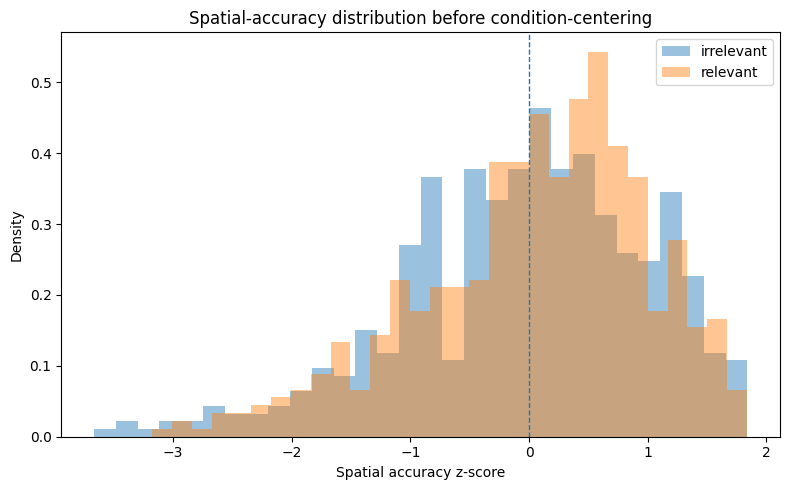

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/figures/spatial_accuracy_distribution_by_relevance_before_condition_centering.png


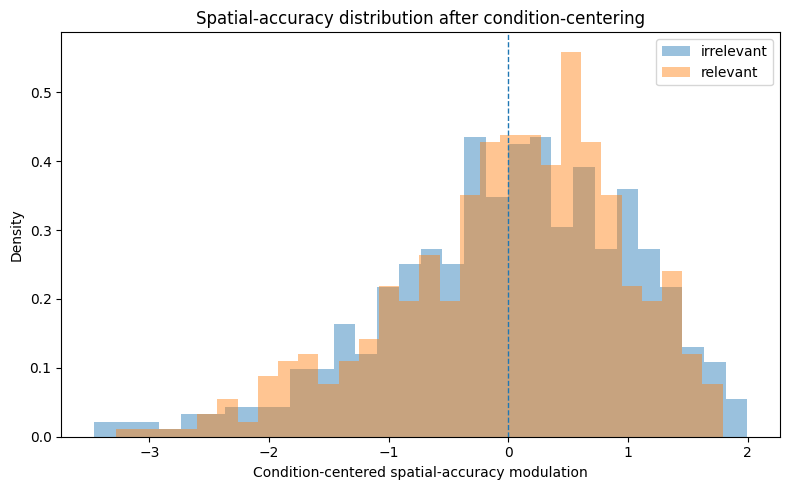

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/figures/spatial_accuracy_distribution_by_relevance_condition_centered.png


,subject,relevance_condition,n_images,mean_modulator,sd_modulator,min_modulator,max_modulator,range_modulator
0,sub-P10,irrelevant,12,0.000000e+00,1.178636,-2.039960,1.906283,3.946243
1,sub-P10,relevant,16,0.000000e+00,0.866742,-1.486046,1.435834,2.921879
2,sub-P12,irrelevant,12,2.775558e-17,0.830648,-1.643291,1.065332,2.708623
3,sub-P12,relevant,18,2.467162e-17,1.128647,-1.731005,1.611309,3.342314
4,sub-P13,irrelevant,21,-1.189525e-17,0.982285,-2.170969,1.083807,3.254776


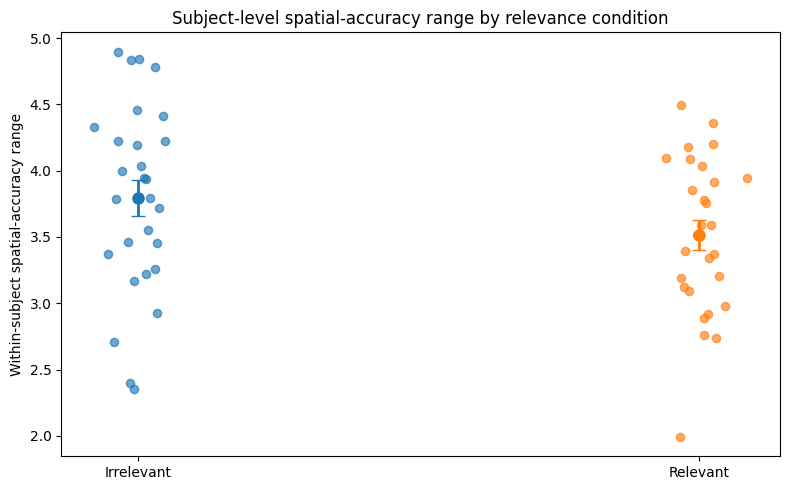

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/figures/subject_level_spatial_accuracy_range_by_relevance.png
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/subject_level_spatial_accuracy_range_by_relevance.csv


In [4]:
# ============================================================
# 4. Plot spatial-accuracy-only modulator distributions
# ============================================================

# ------------------------------------------------------------
# Plot 1: before condition-centering
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

for condition in ["irrelevant", "relevant"]:
    values = spatial_behavior.loc[
        spatial_behavior["relevance_condition"] == condition,
        "spatial_accuracy_z",
    ]
    
    ax.hist(
        values,
        bins=30,
        density=True,
        alpha=0.45,
        label=condition,
    )

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Spatial accuracy z-score")
ax.set_ylabel("Density")
ax.set_title("Spatial-accuracy distribution before condition-centering")
ax.legend()
plt.tight_layout()

out_path = CONTROL_FIG_DIR / "spatial_accuracy_distribution_by_relevance_before_condition_centering.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------------------
# Plot 2: after condition-centering
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

for condition in ["irrelevant", "relevant"]:
    values = spatial_behavior.loc[
        spatial_behavior["relevance_condition"] == condition,
        "spatial_accuracy_condition_centered",
    ]
    
    ax.hist(
        values,
        bins=30,
        density=True,
        alpha=0.45,
        label=condition,
    )

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Condition-centered spatial-accuracy modulation")
ax.set_ylabel("Density")
ax.set_title("Spatial-accuracy distribution after condition-centering")
ax.legend()
plt.tight_layout()

out_path = CONTROL_FIG_DIR / "spatial_accuracy_distribution_by_relevance_condition_centered.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------------------
# Plot 3: subject-level ranges by relevance
# ------------------------------------------------------------

subject_range_df = (
    spatial_behavior
    .groupby(["subject", "relevance_condition"])
    .agg(
        n_images=("image_file", "count"),
        mean_modulator=("spatial_accuracy_condition_centered", "mean"),
        sd_modulator=("spatial_accuracy_condition_centered", "std"),
        min_modulator=("spatial_accuracy_condition_centered", "min"),
        max_modulator=("spatial_accuracy_condition_centered", "max"),
    )
    .reset_index()
)

subject_range_df["range_modulator"] = (
    subject_range_df["max_modulator"] - subject_range_df["min_modulator"]
)

display(subject_range_df.head())

fig, ax = plt.subplots(figsize=(8, 5))

conditions = ["irrelevant", "relevant"]
x_positions = np.arange(len(conditions))
rng = np.random.default_rng(42)

for i, condition in enumerate(conditions):
    values = subject_range_df.loc[
        subject_range_df["relevance_condition"] == condition,
        "range_modulator",
    ].values
    
    jitter = rng.normal(loc=0, scale=0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), x_positions[i]) + jitter,
        values,
        alpha=0.65,
        s=35,
    )
    
    ax.errorbar(
        x_positions[i],
        np.mean(values),
        yerr=np.std(values, ddof=1) / np.sqrt(len(values)),
        marker="o",
        markersize=8,
        capsize=5,
        linewidth=2,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(["Irrelevant", "Relevant"])
ax.set_ylabel("Within-subject spatial-accuracy range")
ax.set_title("Subject-level spatial-accuracy range by relevance condition")
plt.tight_layout()

out_path = CONTROL_FIG_DIR / "subject_level_spatial_accuracy_range_by_relevance.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

subject_range_path = CONTROL_TABLE_DIR / "subject_level_spatial_accuracy_range_by_relevance.csv"
subject_range_df.to_csv(subject_range_path, index=False)

print("Saved:", subject_range_path)

In [8]:
# ============================================================
# 5. Create spatial-accuracy-only GLM event files
# robust version: infer actual rows and relevance from trial_type
# ============================================================

primary_glm_events_long_path = PRIMARY_TABLE_DIR / "final_all_subjects_glm_events_long.csv"

print("Loading primary GLM event backbone:")
print(primary_glm_events_long_path)
print("exists:", primary_glm_events_long_path.exists())

assert primary_glm_events_long_path.exists(), (
    f"Missing primary GLM event backbone: {primary_glm_events_long_path}"
)

primary_glm_events_long = pd.read_csv(primary_glm_events_long_path)

print("\nPrimary GLM event backbone shape:")
print(primary_glm_events_long.shape)

print("\nColumns:")
print(primary_glm_events_long.columns.tolist())

print("\nTrial types in primary GLM backbone:")
display(
    primary_glm_events_long["trial_type"]
    .value_counts()
    .rename_axis("trial_type")
    .reset_index(name="n_rows")
)

display(primary_glm_events_long.head())


# ------------------------------------------------------------
# Infer actual-presentation rows.
# ------------------------------------------------------------

actual_presentation_trial_types = [
    "new_image",
    "old_relevant_valid_main",
    "old_irrelevant_valid_main",
    "old_seen_water_no_spatial_recall",
    "old_other_no_memory_quality",
]

actual_events = primary_glm_events_long.loc[
    primary_glm_events_long["trial_type"].isin(actual_presentation_trial_types)
].copy()

actual_events["row_role"] = "actual_presentation"

print("\nActual-presentation rows:")
print(actual_events.shape)

print("\nActual-presentation trial types:")
display(
    actual_events["trial_type"]
    .value_counts()
    .rename_axis("trial_type")
    .reset_index(name="n_rows")
)

actual_event_qc = (
    actual_events
    .groupby("subject")
    .agg(
        n_actual_presentations=("trial_type", "count"),
        n_unique_images=("image_file", "nunique"),
    )
    .reset_index()
)

display(actual_event_qc)

bad_actual_counts = actual_event_qc.loc[
    actual_event_qc["n_actual_presentations"] != 384
].copy()

print("\nSubjects with actual-presentation count != 384:")
display(bad_actual_counts)

assert bad_actual_counts.empty, (
    "Some subjects do not have 384 actual image-presentation rows in the primary backbone."
)


# ------------------------------------------------------------
# Merge spatial-accuracy-only modulators.
# Only merge the columns we actually need.
# Relevance will be inferred from trial_type, not from goal_relevant.
# ------------------------------------------------------------

spatial_modulator_cols = [
    "subject",
    "image_file",
    "spatial_accuracy_z",
    "spatial_accuracy_condition_centered",
]

spatial_modulators = spatial_behavior[spatial_modulator_cols].copy()

actual_events_spatial = actual_events.merge(
    spatial_modulators,
    on=["subject", "image_file"],
    how="left",
)

actual_events_spatial["has_spatial_accuracy_modulator"] = (
    actual_events_spatial["spatial_accuracy_condition_centered"].notna()
)

print("\nAfter merging spatial modulators:")
display(
    actual_events_spatial
    .groupby("trial_type")
    .agg(
        n_rows=("trial_type", "count"),
        n_with_spatial_modulator=("has_spatial_accuracy_modulator", "sum"),
    )
    .reset_index()
)

new_has_mod = actual_events_spatial.loc[
    actual_events_spatial["trial_type"] == "new_image",
    "has_spatial_accuracy_modulator",
].sum()

print("\nNew-image rows with spatial modulator:", new_has_mod)
assert new_has_mod == 0, "New images should not have spatial-accuracy modulators."


# ------------------------------------------------------------
# Build new spatial-accuracy-only GLM event files.
# ------------------------------------------------------------

all_subject_event_rows = []
event_file_qc_rows = []

for subject, sub_events in actual_events_spatial.groupby("subject", sort=True):
    rows = []
    
    for _, ev in sub_events.iterrows():
        base = {
            "onset": ev["onset"],
            "duration": ev["duration"],
            "image_file": ev["image_file"],
            "original_trial_type": ev["trial_type"],
        }
        
        if ev["trial_type"] == "new_image":
            rows.append({
                **base,
                "trial_type": "new_image",
                "modulation": 1.0,
                "row_role": "actual_presentation",
            })
        
        elif ev["trial_type"] == "old_seen_water_no_spatial_recall":
            rows.append({
                **base,
                "trial_type": "old_seen_water_no_spatial_recall",
                "modulation": 1.0,
                "row_role": "actual_presentation",
            })
        
        elif (
            ev["trial_type"] == "old_relevant_valid_main"
            and ev["has_spatial_accuracy_modulator"]
        ):
            rows.append({
                **base,
                "trial_type": "old_relevant_valid_main",
                "modulation": 1.0,
                "row_role": "actual_presentation",
            })
            rows.append({
                **base,
                "trial_type": "old_relevant_spatial_accuracy",
                "modulation": ev["spatial_accuracy_condition_centered"],
                "row_role": "parametric_modulator",
            })
        
        elif (
            ev["trial_type"] == "old_irrelevant_valid_main"
            and ev["has_spatial_accuracy_modulator"]
        ):
            rows.append({
                **base,
                "trial_type": "old_irrelevant_valid_main",
                "modulation": 1.0,
                "row_role": "actual_presentation",
            })
            rows.append({
                **base,
                "trial_type": "old_irrelevant_spatial_accuracy",
                "modulation": ev["spatial_accuracy_condition_centered"],
                "row_role": "parametric_modulator",
            })
        
        else:
            rows.append({
                **base,
                "trial_type": "old_other_no_spatial_accuracy",
                "modulation": 1.0,
                "row_role": "actual_presentation",
            })
    
    subject_events = pd.DataFrame(rows)
    
    subject_events = subject_events.sort_values(
        ["onset", "row_role", "trial_type"]
    ).reset_index(drop=True)
    
    out_path = (
        CONTROL_EVENTS_DIR
        / f"{subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_events_spatial_accuracy.tsv"
    )
    
    subject_events.to_csv(out_path, sep="\t", index=False)
    
    all_subject_event_rows.append(subject_events.assign(subject=subject))
    
    event_counts = subject_events["trial_type"].value_counts().to_dict()
    
    event_file_qc_rows.append({
        "subject": subject,
        "n_rows": len(subject_events),
        "n_actual_presentations": int(
            (subject_events["row_role"] == "actual_presentation").sum()
        ),
        "n_parametric_rows": int(
            (subject_events["row_role"] == "parametric_modulator").sum()
        ),
        "events_path": str(out_path),
        **event_counts,
    })

all_spatial_glm_events = pd.concat(all_subject_event_rows, ignore_index=True)
spatial_event_file_qc = pd.DataFrame(event_file_qc_rows).fillna(0)

print("\nSpatial-accuracy-only event file QC:")
display(spatial_event_file_qc)

bad_counts = spatial_event_file_qc.loc[
    spatial_event_file_qc["n_actual_presentations"] != 384
].copy()

print("\nSubjects with final actual-presentation count != 384:")
display(bad_counts)

assert bad_counts.empty, "Some subjects do not have 384 actual presentations."


# ------------------------------------------------------------
# Primary-subject QC.
# ------------------------------------------------------------

primary_event_qc = spatial_event_file_qc.loc[
    spatial_event_file_qc["subject"].isin(primary_subjects_final)
].copy()

print("\nPrimary-subject event QC:")
display(primary_event_qc)

assert len(primary_event_qc) == len(primary_subjects_final), (
    "Primary event QC does not include all primary subjects."
)

assert (primary_event_qc["n_actual_presentations"] == 384).all(), (
    "Some primary subjects do not have 384 actual presentations."
)

assert (primary_event_qc["old_relevant_spatial_accuracy"] > 0).all(), (
    "Some primary subjects have no relevant spatial-accuracy parametric rows."
)

assert (primary_event_qc["old_irrelevant_spatial_accuracy"] > 0).all(), (
    "Some primary subjects have no irrelevant spatial-accuracy parametric rows."
)


# ------------------------------------------------------------
# Save.
# ------------------------------------------------------------

all_events_path = CONTROL_TABLE_DIR / "all_subjects_spatial_accuracy_glm_events_long.csv"
event_qc_path = CONTROL_TABLE_DIR / "spatial_accuracy_glm_event_file_qc.csv"
primary_event_qc_path = CONTROL_TABLE_DIR / "spatial_accuracy_glm_primary_event_file_qc.csv"

all_spatial_glm_events.to_csv(all_events_path, index=False)
spatial_event_file_qc.to_csv(event_qc_path, index=False)
primary_event_qc.to_csv(primary_event_qc_path, index=False)

print("\nSaved:")
print(all_events_path)
print(event_qc_path)
print(primary_event_qc_path)

Loading primary GLM event backbone:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_all_subjects_glm_events_long.csv
exists: True

Primary GLM event backbone shape:
(18174, 15)

Columns:
['subject', 'onset', 'duration', 'image_file', 'memory_quality_z', 'memory_quality_condition_centered', 'spatial_accuracy_z', 'confidence_z', 'goal_relevant', 'goal_irrelevant', 'relevance_condition', 'likely_water_placement', 'valid_spatial_placement', 'trial_type', 'modulation']

Trial types in primary GLM backbone:


,trial_type,n_rows
0,old_relevant_valid_main,3240
1,old_relevant_memory_quality,3240
2,old_irrelevant_valid_main,3030
3,old_irrelevant_memory_quality,3030
4,new_image,2976
5,old_other_no_memory_quality,2298
6,old_seen_water_no_spatial_recall,360


,subject,onset,duration,image_file,memory_quality_z,memory_quality_condition_centered,spatial_accuracy_z,confidence_z,goal_relevant,goal_irrelevant,relevance_condition,likely_water_placement,valid_spatial_placement,trial_type,modulation
0,sub-P10,4.632,3.034,maya_3_e3_6_r_h_v1_old.jpg,NaN,NaN,NaN,NaN,False,False,NaN,False,False,old_other_no_memory_quality,1.000000
1,sub-P10,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,0.505430,0.549340,-0.309192,1.166425,False,True,irrelevant,False,True,old_irrelevant_valid_main,1.000000
2,sub-P10,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,0.505430,0.549340,-0.309192,1.166425,False,True,irrelevant,False,True,old_irrelevant_memory_quality,0.549340
3,sub-P10,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,0.433616,0.400684,0.462052,0.273381,True,False,relevant,False,True,old_relevant_valid_main,1.000000
4,sub-P10,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,0.433616,0.400684,0.462052,0.273381,True,False,relevant,False,True,old_relevant_memory_quality,0.400684



Actual-presentation rows:
(11904, 16)

Actual-presentation trial types:


,trial_type,n_rows
0,old_relevant_valid_main,3240
1,old_irrelevant_valid_main,3030
2,new_image,2976
3,old_other_no_memory_quality,2298
4,old_seen_water_no_spatial_recall,360


...


Subjects with final actual-presentation count != 384:


,subject,n_rows,n_actual_presentations,n_parametric_rows,events_path,old_other_no_spatial_accuracy,old_relevant_valid_main,new_image,old_relevant_spatial_accuracy,old_irrelevant_valid_main,old_irrelevant_spatial_accuracy,old_seen_water_no_spatial_recall



Primary-subject event QC:


,subject,n_rows,n_actual_presentations,n_parametric_rows,events_path,old_other_no_spatial_accuracy,old_relevant_valid_main,new_image,old_relevant_spatial_accuracy,old_irrelevant_valid_main,old_irrelevant_spatial_accuracy,old_seen_water_no_spatial_recall
0,sub-P10,552,384,168,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,120.0,96.0,96,96.0,72.0,72.0,0.0
1,sub-P12,564,384,180,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,108.0,108.0,96,108.0,72.0,72.0,0.0
2,sub-P13,636,384,252,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,36.0,126.0,96,126.0,126.0,126.0,0.0
3,sub-P14,666,384,282,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,6.0,138.0,96,138.0,144.0,144.0,0.0
4,sub-P15,594,384,210,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,0.0,120.0,96,120.0,90.0,90.0,78.0
5,sub-P16,624,384,240,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,42.0,120.0,96,120.0,120.0,120.0,6.0
6,sub-P17,570,384,186,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,102.0,96.0,96,96.0,90.0,90.0,0.0
7,sub-P18,642,384,258,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,24.0,126.0,96,126.0,132.0,132.0,6.0
8,sub-P19,594,384,210,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,66.0,102.0,96,102.0,108.0,108.0,12.0
10,sub-P21,588,384,204,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,78.0,108.0,96,108.0,96.0,96.0,6.0



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/all_subjects_spatial_accuracy_glm_events_long.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/spatial_accuracy_glm_event_file_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/spatial_accuracy_glm_primary_event_file_qc.csv


In [9]:
# ============================================================
# 6. Define spatial-accuracy-only contrasts
# ============================================================

SPATIAL_ACCURACY_CONTRASTS = {
    # Primary control contrast
    "all_spatial_accuracy_positive": {
        "old_relevant_spatial_accuracy": 0.5,
        "old_irrelevant_spatial_accuracy": 0.5,
    },
    
    # Secondary condition-specific checks
    "relevant_spatial_accuracy_positive": {
        "old_relevant_spatial_accuracy": 1.0,
    },
    "irrelevant_spatial_accuracy_positive": {
        "old_irrelevant_spatial_accuracy": 1.0,
    },
    
    # Secondary interaction check
    "relevant_gt_irrelevant_spatial_accuracy": {
        "old_relevant_spatial_accuracy": 1.0,
        "old_irrelevant_spatial_accuracy": -1.0,
    },
}

contrast_interpretations = {
    "all_spatial_accuracy_positive": (
        "Primary control: BOLD increases with later spatial accuracy across relevant and irrelevant images."
    ),
    "relevant_spatial_accuracy_positive": (
        "Secondary: BOLD increases with later spatial accuracy among relevant images."
    ),
    "irrelevant_spatial_accuracy_positive": (
        "Secondary: BOLD increases with later spatial accuracy among irrelevant images."
    ),
    "relevant_gt_irrelevant_spatial_accuracy": (
        "Secondary interaction: spatial-accuracy slope is stronger for relevant than irrelevant images."
    ),
}

contrast_priority = {
    "all_spatial_accuracy_positive": "primary",
    "relevant_spatial_accuracy_positive": "secondary_condition_specific",
    "irrelevant_spatial_accuracy_positive": "secondary_condition_specific",
    "relevant_gt_irrelevant_spatial_accuracy": "secondary_interaction",
}

print("Spatial-accuracy-only contrasts:")
for name, weights in SPATIAL_ACCURACY_CONTRASTS.items():
    print("\n", name)
    print("  priority:", contrast_priority[name])
    print("  weights:", weights)
    print("  interpretation:", contrast_interpretations[name])

contrast_summary = pd.DataFrame([
    {
        "contrast": name,
        "priority": contrast_priority[name],
        "weights": str(weights),
        "interpretation": contrast_interpretations[name],
    }
    for name, weights in SPATIAL_ACCURACY_CONTRASTS.items()
])

display(contrast_summary)

contrast_summary_path = CONTROL_TABLE_DIR / "spatial_accuracy_only_contrast_summary.csv"
contrast_summary.to_csv(contrast_summary_path, index=False)

print("Saved:", contrast_summary_path)

Spatial-accuracy-only contrasts:

 all_spatial_accuracy_positive
  priority: primary
  weights: {'old_relevant_spatial_accuracy': 0.5, 'old_irrelevant_spatial_accuracy': 0.5}
  interpretation: Primary control: BOLD increases with later spatial accuracy across relevant and irrelevant images.

 relevant_spatial_accuracy_positive
  priority: secondary_condition_specific
  weights: {'old_relevant_spatial_accuracy': 1.0}
  interpretation: Secondary: BOLD increases with later spatial accuracy among relevant images.

 irrelevant_spatial_accuracy_positive
  priority: secondary_condition_specific
  weights: {'old_irrelevant_spatial_accuracy': 1.0}
  interpretation: Secondary: BOLD increases with later spatial accuracy among irrelevant images.

 relevant_gt_irrelevant_spatial_accuracy
  priority: secondary_interaction
  weights: {'old_relevant_spatial_accuracy': 1.0, 'old_irrelevant_spatial_accuracy': -1.0}
  interpretation: Secondary interaction: spatial-accuracy slope is stronger for relevant 

,contrast,priority,weights,interpretation
0,all_spatial_accuracy_positive,primary,"{'old_relevant_spatial_accuracy': 0.5, 'old_ir...",Primary control: BOLD increases with later spa...
1,relevant_spatial_accuracy_positive,secondary_condition_specific,{'old_relevant_spatial_accuracy': 1.0},Secondary: BOLD increases with later spatial a...
2,irrelevant_spatial_accuracy_positive,secondary_condition_specific,{'old_irrelevant_spatial_accuracy': 1.0},Secondary: BOLD increases with later spatial a...
3,relevant_gt_irrelevant_spatial_accuracy,secondary_interaction,"{'old_relevant_spatial_accuracy': 1.0, 'old_ir...",Secondary interaction: spatial-accuracy slope ...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/spatial_accuracy_only_contrast_summary.csv


In [10]:
# ============================================================
# 7. First-level helper functions for spatial-accuracy-only GLM
# ============================================================

from nilearn.glm.first_level import FirstLevelModel
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.plotting import plot_design_matrix

SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = f"smoothed{int(SMOOTHING_FWHM)}mm"

FIRST_LEVEL_DIR = CONTROL_OUT_DIR / f"first_level_{SMOOTHING_LABEL}"
FIRST_LEVEL_MAPS_DIR = FIRST_LEVEL_DIR / "maps"
FIRST_LEVEL_DESIGN_DIR = FIRST_LEVEL_DIR / "design_matrices"
FIRST_LEVEL_FIG_DIR = FIRST_LEVEL_DIR / "figures"

for path in [
    FIRST_LEVEL_DIR,
    FIRST_LEVEL_MAPS_DIR,
    FIRST_LEVEL_DESIGN_DIR,
    FIRST_LEVEL_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


def expected_post_bold_file(subject, space=BOLD_SPACE):
    return (
        FMRIPREP_DIR
        / subject
        / POST_SESSION
        / "func"
        / f"{subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_space-{space}_desc-preproc_bold.nii.gz"
    )


def expected_post_events_spatial_file(subject):
    return (
        CONTROL_EVENTS_DIR
        / f"{subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_events_spatial_accuracy.tsv"
    )


def load_spatial_accuracy_events_for_glm(subject):
    events_path = expected_post_events_spatial_file(subject)
    assert events_path.exists(), f"Missing events file: {events_path}"
    
    events = pd.read_csv(events_path, sep="\t")
    
    # Nilearn only needs these columns.
    events_glm = events[["onset", "duration", "trial_type", "modulation"]].copy()
    
    return events, events_glm, events_path


def load_bold_and_confounds(subject):
    bold_path = expected_post_bold_file(subject)
    assert bold_path.exists(), f"Missing BOLD file: {bold_path}"
    
    bold_img = nib.load(str(bold_path))
    tr = float(bold_img.header.get_zooms()[3])
    
    confounds, sample_mask = load_confounds(
        str(bold_path),
        strategy=["motion", "wm_csf", "high_pass"],
        motion="full",
        wm_csf="basic",
    )
    
    return bold_img, bold_path, tr, confounds, sample_mask


def make_contrast_vector(design_columns, contrast_weights):
    contrast_vector = np.zeros(len(design_columns))
    
    missing_columns = []
    
    for column_name, weight in contrast_weights.items():
        if column_name in design_columns:
            contrast_vector[list(design_columns).index(column_name)] = weight
        else:
            missing_columns.append(column_name)
    
    return contrast_vector, missing_columns


def fit_first_level_spatial_accuracy(subject, smoothing_fwhm=SMOOTHING_FWHM):
    events_full, events_glm, events_path = load_spatial_accuracy_events_for_glm(subject)
    bold_img, bold_path, tr, confounds, sample_mask = load_bold_and_confounds(subject)
    
    model = FirstLevelModel(
        t_r=tr,
        hrf_model="spm",
        drift_model=None,          # high-pass cosines are already in confounds
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        smoothing_fwhm=smoothing_fwhm,
        minimize_memory=False,
    )
    
    model = model.fit(
        run_imgs=bold_img,
        events=events_glm,
        confounds=confounds,
        sample_masks=sample_mask,
    )
    
    design_matrix = model.design_matrices_[0]
    design_columns = design_matrix.columns.tolist()
    
    return {
        "subject": subject,
        "model": model,
        "events_full": events_full,
        "events_glm": events_glm,
        "events_path": events_path,
        "bold_path": bold_path,
        "tr": tr,
        "n_scans": bold_img.shape[-1],
        "confounds": confounds,
        "sample_mask": sample_mask,
        "design_matrix": design_matrix,
        "design_columns": design_columns,
    }


def save_spatial_accuracy_contrasts(fit_result):
    subject = fit_result["subject"]
    model = fit_result["model"]
    design_columns = fit_result["design_columns"]
    
    saved_rows = []
    
    for contrast_name, contrast_weights in SPATIAL_ACCURACY_CONTRASTS.items():
        contrast_vector, missing_columns = make_contrast_vector(
            design_columns,
            contrast_weights,
        )
        
        if len(missing_columns) > 0:
            print(f"WARNING {subject} {contrast_name}: missing columns {missing_columns}")
        
        z_map = model.compute_contrast(
            contrast_vector,
            output_type="z_score",
        )
        
        effect_map = model.compute_contrast(
            contrast_vector,
            output_type="effect_size",
        )
        
        z_path = (
            FIRST_LEVEL_MAPS_DIR
            / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"
        )
        effect_path = (
            FIRST_LEVEL_MAPS_DIR
            / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
        )
        
        z_map.to_filename(z_path)
        effect_map.to_filename(effect_path)
        
        saved_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "missing_columns": ";".join(missing_columns),
            "z_map_path": str(z_path),
            "effect_map_path": str(effect_path),
            "z_map_exists": z_path.exists(),
            "effect_map_exists": effect_path.exists(),
        })
    
    return pd.DataFrame(saved_rows)


print("First-level spatial-accuracy-only helper functions ready.")
print("Output directory:", FIRST_LEVEL_DIR)

First-level spatial-accuracy-only helper functions ready.
Output directory: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/first_level_smoothed5mm


[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Single-subject spatial-accuracy-only GLM completed
Subject: sub-P15
Design matrix shape: (1995, 72)
Number of scans: 1995
TR: 1.2999999523162842
Smoothing FWHM: 5.0

Event columns in design matrix:
  - new_image
  - old_irrelevant_spatial_accuracy
  - old_irrelevant_valid_main
  - old_relevant_spatial_accuracy
  - old_relevant_valid_main
  - old_seen_water_no_spatial_recall

Events full counts:


,trial_type,row_role,n_rows
0,new_image,actual_presentation,96
1,old_irrelevant_spatial_accuracy,parametric_modulator,90
2,old_irrelevant_valid_main,actual_presentation,90
3,old_relevant_spatial_accuracy,parametric_modulator,120
4,old_relevant_valid_main,actual_presentation,120
5,old_seen_water_no_spatial_recall,actual_presentation,78



Spatial-accuracy modulator summary:


,trial_type,n_rows,mean_modulation,sd_modulation,min_modulation,max_modulation
0,old_irrelevant_spatial_accuracy,90,0.000000e+00,1.082866,-2.922932,1.406845
1,old_relevant_spatial_accuracy,120,-4.625929e-19,0.929252,-3.276716,0.902039



Saved design matrix:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/first_level_smoothed5mm/design_matrices/sub-P15_spatial_accuracy_smoothed5mm_design_matrix.csv


/tmp/ipykernel_196014/3042247338.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

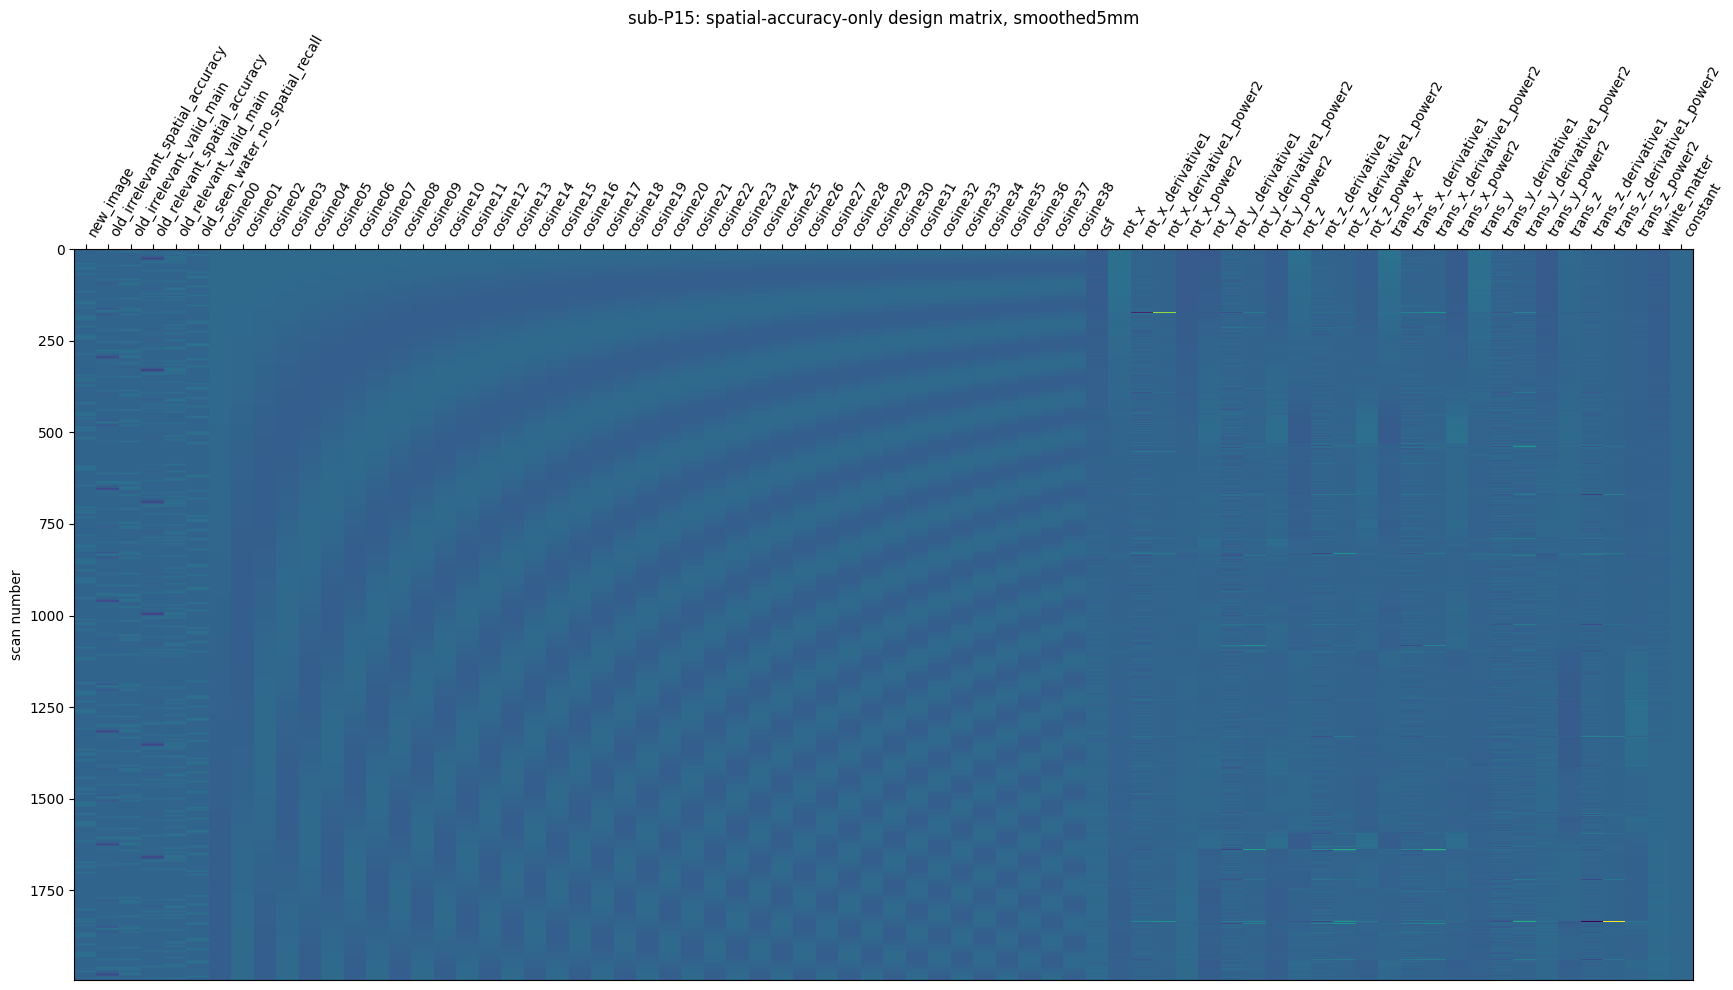

Saved design figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/first_level_smoothed5mm/figures/sub-P15_spatial_accuracy_smoothed5mm_design_matrix.png


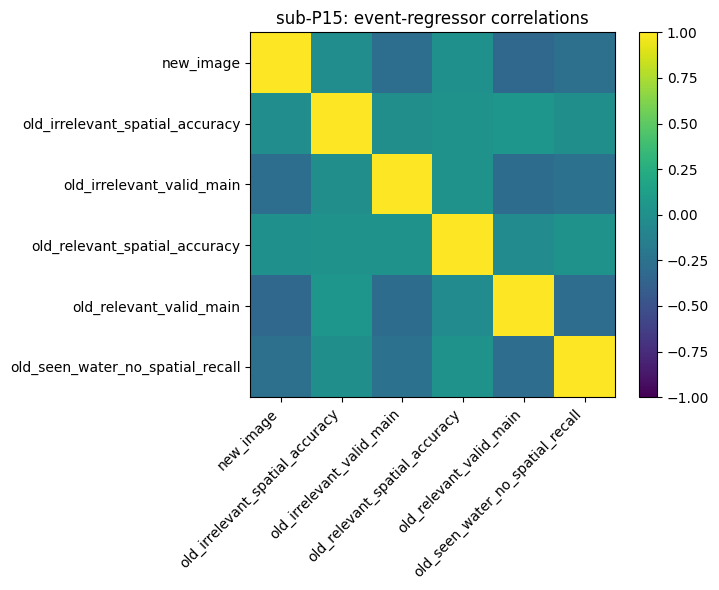

Saved correlation figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/first_level_smoothed5mm/figures/sub-P15_spatial_accuracy_smoothed5mm_event_regressor_correlations.png

Saved test contrast maps:


,subject,contrast,missing_columns,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,sub-P15,all_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
1,sub-P15,relevant_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
2,sub-P15,irrelevant_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
3,sub-P15,relevant_gt_irrelevant_spatial_accuracy,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/sub-P15_spatial_accuracy_single_subject_contrast_qc.csv


In [11]:
# ============================================================
# 8. Single-subject sanity check: spatial-accuracy-only GLM
# ============================================================

test_subject = "sub-P15"

fit_test = fit_first_level_spatial_accuracy(
    test_subject,
    smoothing_fwhm=SMOOTHING_FWHM,
)

design_matrix = fit_test["design_matrix"]
events_full = fit_test["events_full"]

event_columns = [
    col for col in design_matrix.columns
    if col.startswith("old_") or col == "new_image"
]

print("Single-subject spatial-accuracy-only GLM completed")
print("=" * 80)
print("Subject:", test_subject)
print("Design matrix shape:", design_matrix.shape)
print("Number of scans:", fit_test["n_scans"])
print("TR:", fit_test["tr"])
print("Smoothing FWHM:", SMOOTHING_FWHM)

print("\nEvent columns in design matrix:")
for col in event_columns:
    print("  -", col)

print("\nEvents full counts:")
display(
    events_full
    .groupby(["trial_type", "row_role"])
    .size()
    .reset_index(name="n_rows")
)

print("\nSpatial-accuracy modulator summary:")
display(
    events_full
    .loc[
        events_full["trial_type"].isin([
            "old_relevant_spatial_accuracy",
            "old_irrelevant_spatial_accuracy",
        ])
    ]
    .groupby("trial_type")
    .agg(
        n_rows=("modulation", "count"),
        mean_modulation=("modulation", "mean"),
        sd_modulation=("modulation", "std"),
        min_modulation=("modulation", "min"),
        max_modulation=("modulation", "max"),
    )
    .reset_index()
)

# Save design matrix
design_matrix_path = (
    FIRST_LEVEL_DESIGN_DIR
    / f"{test_subject}_spatial_accuracy_{SMOOTHING_LABEL}_design_matrix.csv"
)
design_matrix.to_csv(design_matrix_path)

print("\nSaved design matrix:")
print(design_matrix_path)

# Plot design matrix
fig = plt.figure(figsize=(14, 8))
plot_design_matrix(design_matrix)
plt.title(f"{test_subject}: spatial-accuracy-only design matrix, {SMOOTHING_LABEL}")
plt.tight_layout()

design_fig_path = (
    FIRST_LEVEL_FIG_DIR
    / f"{test_subject}_spatial_accuracy_{SMOOTHING_LABEL}_design_matrix.png"
)
fig.savefig(design_fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved design figure:")
print(design_fig_path)

# Event-regressor correlation matrix
event_design = design_matrix[event_columns].copy()
corr = event_design.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(event_columns)))
ax.set_yticks(np.arange(len(event_columns)))
ax.set_xticklabels(event_columns, rotation=45, ha="right")
ax.set_yticklabels(event_columns)
ax.set_title(f"{test_subject}: event-regressor correlations")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

corr_fig_path = (
    FIRST_LEVEL_FIG_DIR
    / f"{test_subject}_spatial_accuracy_{SMOOTHING_LABEL}_event_regressor_correlations.png"
)
fig.savefig(corr_fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved correlation figure:")
print(corr_fig_path)

# Save test contrasts
test_contrast_qc = save_spatial_accuracy_contrasts(fit_test)

print("\nSaved test contrast maps:")
display(test_contrast_qc)

test_contrast_qc_path = (
    CONTROL_TABLE_DIR
    / f"{test_subject}_spatial_accuracy_single_subject_contrast_qc.csv"
)
test_contrast_qc.to_csv(test_contrast_qc_path, index=False)

print("Saved:")
print(test_contrast_qc_path)

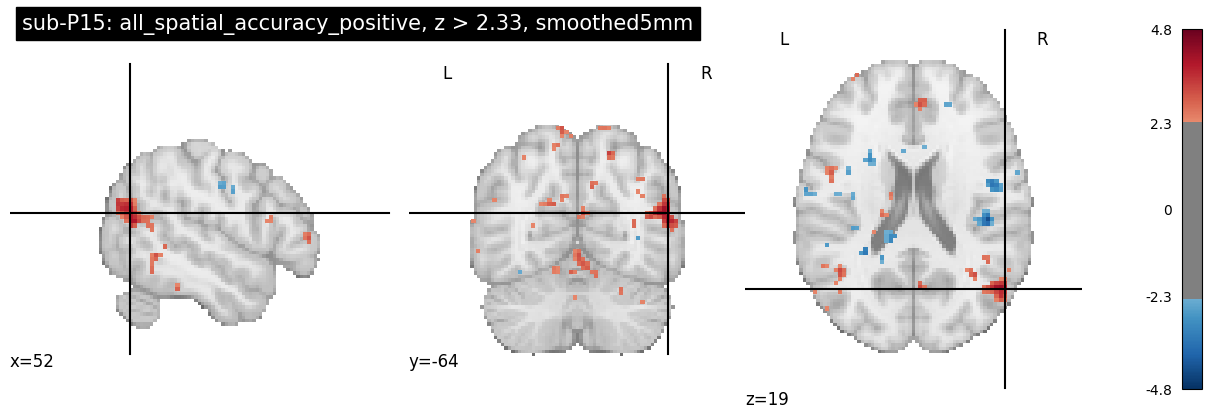

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/first_level_smoothed5mm/figures/sub-P15_all_spatial_accuracy_positive_smoothed5mm_zgt2.33.png


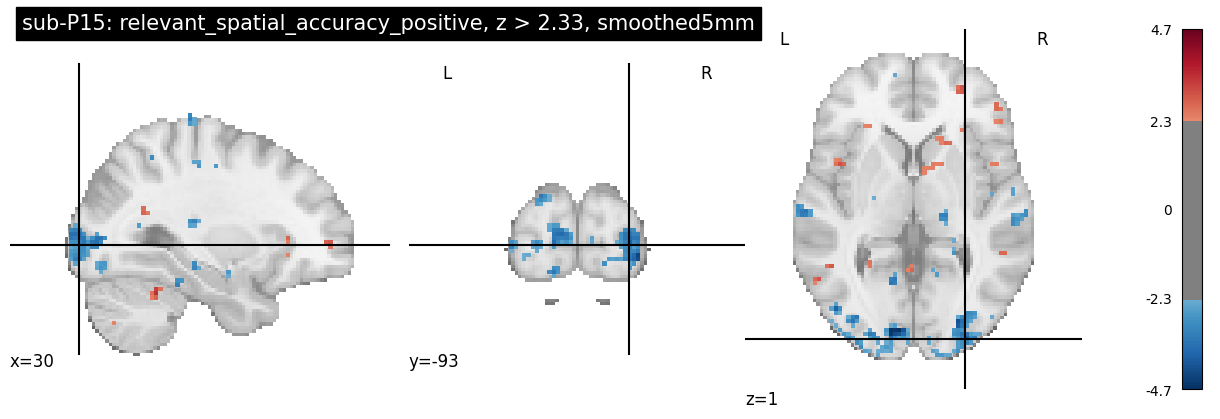

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/first_level_smoothed5mm/figures/sub-P15_relevant_spatial_accuracy_positive_smoothed5mm_zgt2.33.png


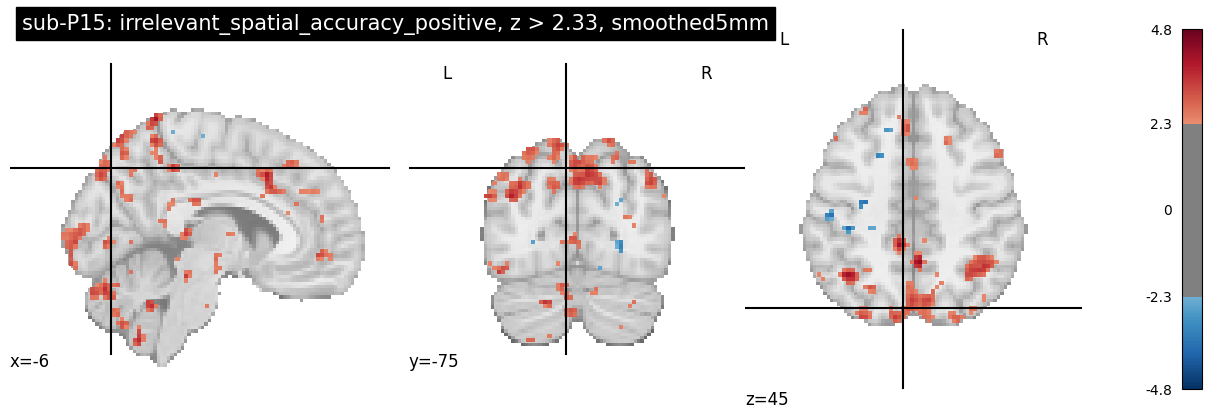

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/first_level_smoothed5mm/figures/sub-P15_irrelevant_spatial_accuracy_positive_smoothed5mm_zgt2.33.png


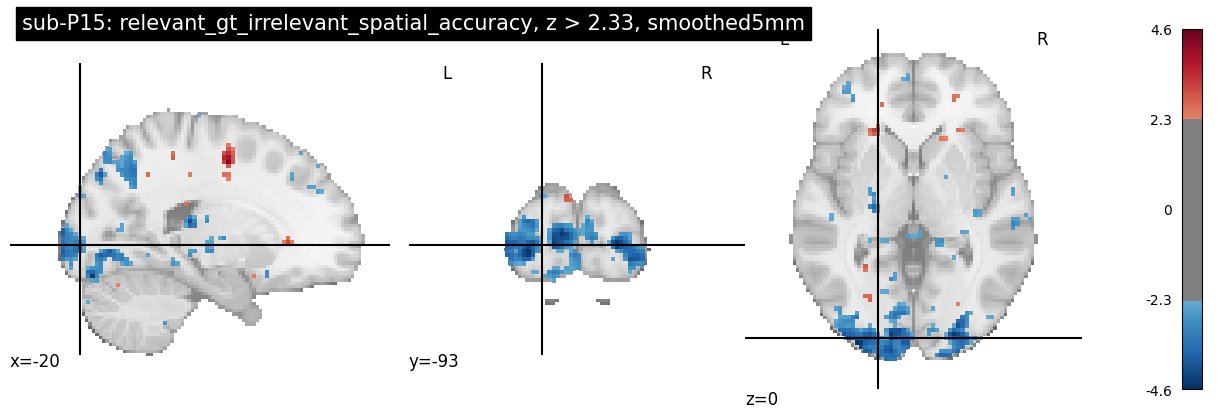

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/first_level_smoothed5mm/figures/sub-P15_relevant_gt_irrelevant_spatial_accuracy_smoothed5mm_zgt2.33.png


In [12]:
# ============================================================
# 9. Visual QC: single-subject spatial-accuracy contrast maps
# ============================================================

from nilearn.plotting import plot_stat_map

test_subject = "sub-P15"

for contrast_name in SPATIAL_ACCURACY_CONTRASTS.keys():
    z_path = (
        FIRST_LEVEL_MAPS_DIR
        / f"{test_subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"
    )
    
    assert z_path.exists(), f"Missing z-map: {z_path}"
    
    z_img = nib.load(str(z_path))
    
    fig = plt.figure(figsize=(12, 4))
    
    plot_stat_map(
        z_img,
        threshold=2.33,
        display_mode="ortho",
        cut_coords=None,
        title=f"{test_subject}: {contrast_name}, z > 2.33, {SMOOTHING_LABEL}",
        figure=fig,
    )
    
    out_path = (
        FIRST_LEVEL_FIG_DIR
        / f"{test_subject}_{contrast_name}_{SMOOTHING_LABEL}_zgt2.33.png"
    )
    
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    
    print("Saved:", out_path)

In [13]:
# ============================================================
# 10. Full first-level loop: spatial-accuracy-only GLM
# ============================================================

from tqdm.auto import tqdm
import traceback

first_level_qc_rows = []
all_contrast_qc_rows = []

print("Running spatial-accuracy-only first-level GLM")
print("=" * 80)
print("Number of primary subjects:", len(primary_subjects_final))
print(primary_subjects_final)
print("Smoothing:", SMOOTHING_FWHM, "mm")
print("Output:", FIRST_LEVEL_MAPS_DIR)

for subject in tqdm(primary_subjects_final):
    print("\n" + "=" * 80)
    print("Subject:", subject)
    
    row = {
        "subject": subject,
        "success": False,
        "error": "",
        "n_scans": np.nan,
        "tr": np.nan,
        "n_design_columns": np.nan,
        "n_event_columns": np.nan,
        "events_path": str(expected_post_events_spatial_file(subject)),
        "bold_path": str(expected_post_bold_file(subject)),
    }
    
    try:
        fit_result = fit_first_level_spatial_accuracy(
            subject,
            smoothing_fwhm=SMOOTHING_FWHM,
        )
        
        design_matrix = fit_result["design_matrix"]
        design_columns = fit_result["design_columns"]
        
        event_columns = [
            col for col in design_columns
            if col.startswith("old_") or col == "new_image"
        ]
        
        # Save design matrix.
        design_matrix_path = (
            FIRST_LEVEL_DESIGN_DIR
            / f"{subject}_spatial_accuracy_{SMOOTHING_LABEL}_design_matrix.csv"
        )
        design_matrix.to_csv(design_matrix_path)
        
        # Save contrast maps.
        contrast_qc = save_spatial_accuracy_contrasts(fit_result)
        all_contrast_qc_rows.append(contrast_qc)
        
        row.update({
            "success": True,
            "n_scans": fit_result["n_scans"],
            "tr": fit_result["tr"],
            "n_design_columns": len(design_columns),
            "n_event_columns": len(event_columns),
            "design_matrix_path": str(design_matrix_path),
            "event_columns": ";".join(event_columns),
        })
        
        print("Success.")
        print("Design matrix:", design_matrix.shape)
        print("Event columns:", event_columns)
        
    except Exception as e:
        row["success"] = False
        row["error"] = repr(e)
        print("FAILED:", repr(e))
        traceback.print_exc()
    
    first_level_qc_rows.append(row)

first_level_qc = pd.DataFrame(first_level_qc_rows)

if len(all_contrast_qc_rows) > 0:
    first_level_contrast_qc = pd.concat(all_contrast_qc_rows, ignore_index=True)
else:
    first_level_contrast_qc = pd.DataFrame()

first_level_qc_path = (
    CONTROL_TABLE_DIR
    / f"first_level_primary_spatial_accuracy_{SMOOTHING_LABEL}_qc.csv"
)

first_level_contrast_qc_path = (
    CONTROL_TABLE_DIR
    / f"first_level_primary_spatial_accuracy_{SMOOTHING_LABEL}_contrast_qc.csv"
)

first_level_qc.to_csv(first_level_qc_path, index=False)
first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)

print("\n" + "=" * 80)
print("First-level spatial-accuracy-only GLM complete.")
print("Success count:", first_level_qc["success"].sum(), "/", len(first_level_qc))

print("\nFirst-level QC:")
display(first_level_qc)

print("\nContrast QC:")
display(first_level_contrast_qc)

print("\nSaved:")
print(first_level_qc_path)
print(first_level_contrast_qc_path)

Running spatial-accuracy-only first-level GLM
Number of primary subjects: 28
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']
Smoothing: 5.0 mm
Output: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/first_level_smoothed5mm/maps


  0%|          | 0/28 [00:00<?, ?it/s]


Subject: sub-P10
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Success.
Design matrix: (1994, 72)
Event columns: ['new_image', 'old_irrelevant_spatial_accuracy', 'old_irrelevant_valid_main', 'old_other_no_spatial_accuracy', 'old_relevant_spatial_accuracy', 'old_relevant_valid_main']

Subject: sub-P12
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Success.
Design matrix: (1954, 71)
Event columns: ['new_image', 'old_irrelevant_spatial_accuracy', 'old_irrelevant_valid_main', 'old_other_no_spatial_accuracy', 'old_relevant_spatial_accuracy', 'old_relevant_valid_main']

Subject: sub-P13
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Success.
Design matrix: (1957, 71)
Event columns: ['new_image', 'old_irrelevant_spatial_accuracy', 'old_irrelevant_valid_main', 'old_other_no_spatial_accuracy', 'old_relevant_spatial_accuracy', 'old_relevant_valid_main']

Subjec

,subject,success,error,n_scans,tr,n_design_columns,n_event_columns,events_path,bold_path,design_matrix_path,event_columns
0,sub-P10,True,,1994,1.3,72,6,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...
1,sub-P12,True,,1954,1.3,71,6,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...
2,sub-P13,True,,1957,1.3,71,6,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...
3,sub-P14,True,,1922,1.3,71,6,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...
4,sub-P15,True,,1995,1.3,72,6,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...
5,sub-P16,True,,1955,1.3,72,7,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...
6,sub-P17,True,,1946,1.3,71,6,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...
7,sub-P18,True,,1993,1.3,73,7,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...
8,sub-P19,True,,1945,1.3,72,7,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...
9,sub-P21,True,,1961,1.3,72,7,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,new_image;old_irrelevant_spatial_accuracy;old_...



Contrast QC:


,subject,contrast,missing_columns,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,sub-P10,all_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
1,sub-P10,relevant_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
2,sub-P10,irrelevant_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
3,sub-P10,relevant_gt_irrelevant_spatial_accuracy,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
4,sub-P12,all_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
...,...,...,...,...,...,...,...
107,sub-P50,relevant_gt_irrelevant_spatial_accuracy,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
108,sub-P51,all_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
109,sub-P51,relevant_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
110,sub-P51,irrelevant_spatial_accuracy_positive,,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/first_level_primary_spatial_accuracy_smoothed5mm_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/first_level_primary_spatial_accuracy_smoothed5mm_contrast_qc.csv


In [14]:
# ============================================================
# 11. Verify all first-level spatial-accuracy maps exist
# ============================================================

expected_map_rows = []

for subject in primary_subjects_final:
    for contrast_name in SPATIAL_ACCURACY_CONTRASTS.keys():
        z_path = (
            FIRST_LEVEL_MAPS_DIR
            / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"
        )
        effect_path = (
            FIRST_LEVEL_MAPS_DIR
            / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
        )
        
        expected_map_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "z_map_exists": z_path.exists(),
            "effect_map_exists": effect_path.exists(),
            "z_map_path": str(z_path),
            "effect_map_path": str(effect_path),
        })

map_existence_qc = pd.DataFrame(expected_map_rows)

display(
    map_existence_qc
    .groupby("contrast")
    .agg(
        n_subjects=("subject", "nunique"),
        n_z_maps=("z_map_exists", "sum"),
        n_effect_maps=("effect_map_exists", "sum"),
    )
    .reset_index()
)

missing_maps = map_existence_qc.loc[
    (~map_existence_qc["z_map_exists"]) | (~map_existence_qc["effect_map_exists"])
].copy()

print("\nMissing maps:")
display(missing_maps)

assert missing_maps.empty, "Some first-level spatial-accuracy maps are missing."

map_existence_qc_path = (
    CONTROL_TABLE_DIR
    / f"first_level_primary_spatial_accuracy_{SMOOTHING_LABEL}_map_existence_qc.csv"
)

map_existence_qc.to_csv(map_existence_qc_path, index=False)

print("Saved:", map_existence_qc_path)

,contrast,n_subjects,n_z_maps,n_effect_maps
0,all_spatial_accuracy_positive,28,28,28
1,irrelevant_spatial_accuracy_positive,28,28,28
2,relevant_gt_irrelevant_spatial_accuracy,28,28,28
3,relevant_spatial_accuracy_positive,28,28,28



Missing maps:


,subject,contrast,z_map_exists,effect_map_exists,z_map_path,effect_map_path


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/first_level_primary_spatial_accuracy_smoothed5mm_map_existence_qc.csv


In [15]:
# ============================================================
# 12. Second-level group GLM: spatial-accuracy-only contrasts
# ============================================================

from nilearn.glm.second_level import SecondLevelModel
from nilearn.plotting import plot_stat_map
from nilearn.image import load_img

SECOND_LEVEL_DIR = CONTROL_OUT_DIR / f"second_level_from_{SMOOTHING_LABEL}"
SECOND_LEVEL_MAPS_DIR = SECOND_LEVEL_DIR / "maps"
SECOND_LEVEL_FIG_DIR = SECOND_LEVEL_DIR / "figures"

for path in [
    SECOND_LEVEL_DIR,
    SECOND_LEVEL_MAPS_DIR,
    SECOND_LEVEL_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


def get_first_level_spatial_effect_map(subject, contrast_name):
    return (
        FIRST_LEVEL_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
    )


def get_group_spatial_z_map(contrast_name):
    return (
        SECOND_LEVEL_MAPS_DIR
        / f"group_primary_{contrast_name}_from_{SMOOTHING_LABEL}_zmap.nii.gz"
    )


def get_group_spatial_effect_map(contrast_name):
    return (
        SECOND_LEVEL_MAPS_DIR
        / f"group_primary_{contrast_name}_from_{SMOOTHING_LABEL}_effect.nii.gz"
    )


second_level_rows = []

print("Running second-level spatial-accuracy-only GLM")
print("=" * 80)
print("Subjects:", len(primary_subjects_final))
print("Smoothing:", SMOOTHING_LABEL)

for contrast_name in SPATIAL_ACCURACY_CONTRASTS.keys():
    print("\n" + "-" * 80)
    print("Contrast:", contrast_name)
    
    effect_paths = [
        get_first_level_spatial_effect_map(subject, contrast_name)
        for subject in primary_subjects_final
    ]
    
    missing = [path for path in effect_paths if not path.exists()]
    assert len(missing) == 0, f"Missing first-level maps for {contrast_name}: {missing}"
    
    second_level_input = [str(path) for path in effect_paths]
    
    design_matrix = pd.DataFrame(
        np.ones((len(second_level_input), 1)),
        columns=["intercept"],
    )
    
    second_level_model = SecondLevelModel(
        smoothing_fwhm=None,
        minimize_memory=False,
    )
    
    second_level_model = second_level_model.fit(
        second_level_input,
        design_matrix=design_matrix,
    )
    
    z_map = second_level_model.compute_contrast(
        second_level_contrast="intercept",
        output_type="z_score",
    )
    
    effect_map = second_level_model.compute_contrast(
        second_level_contrast="intercept",
        output_type="effect_size",
    )
    
    z_path = get_group_spatial_z_map(contrast_name)
    effect_path = get_group_spatial_effect_map(contrast_name)
    
    z_map.to_filename(z_path)
    effect_map.to_filename(effect_path)
    
    second_level_rows.append({
        "contrast": contrast_name,
        "n_subjects": len(second_level_input),
        "z_map_path": str(z_path),
        "effect_map_path": str(effect_path),
        "z_map_exists": z_path.exists(),
        "effect_map_exists": effect_path.exists(),
    })
    
    print("Saved:")
    print("  z:", z_path)
    print("  effect:", effect_path)

second_level_qc = pd.DataFrame(second_level_rows)

second_level_qc_path = (
    CONTROL_TABLE_DIR
    / f"second_level_primary_spatial_accuracy_from_{SMOOTHING_LABEL}_qc.csv"
)

second_level_qc.to_csv(second_level_qc_path, index=False)

print("\nSecond-level QC:")
display(second_level_qc)

assert second_level_qc["z_map_exists"].all()
assert second_level_qc["effect_map_exists"].all()

print("\nSaved:", second_level_qc_path)

Running second-level spatial-accuracy-only GLM
Subjects: 28
Smoothing: smoothed5mm

--------------------------------------------------------------------------------
Contrast: all_spatial_accuracy_positive
Saved:
  z: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/maps/group_primary_all_spatial_accuracy_positive_from_smoothed5mm_zmap.nii.gz
  effect: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/maps/group_primary_all_spatial_accuracy_positive_from_smoothed5mm_effect.nii.gz

--------------------------------------------------------------------------------
Contrast: relevant_spatial_accuracy_positive
Saved:
  z: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoot

,contrast,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,all_spatial_accuracy_positive,28,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
1,relevant_spatial_accuracy_positive,28,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
2,irrelevant_spatial_accuracy_positive,28,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
3,relevant_gt_irrelevant_spatial_accuracy,28,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True



Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/second_level_primary_spatial_accuracy_from_smoothed5mm_qc.csv


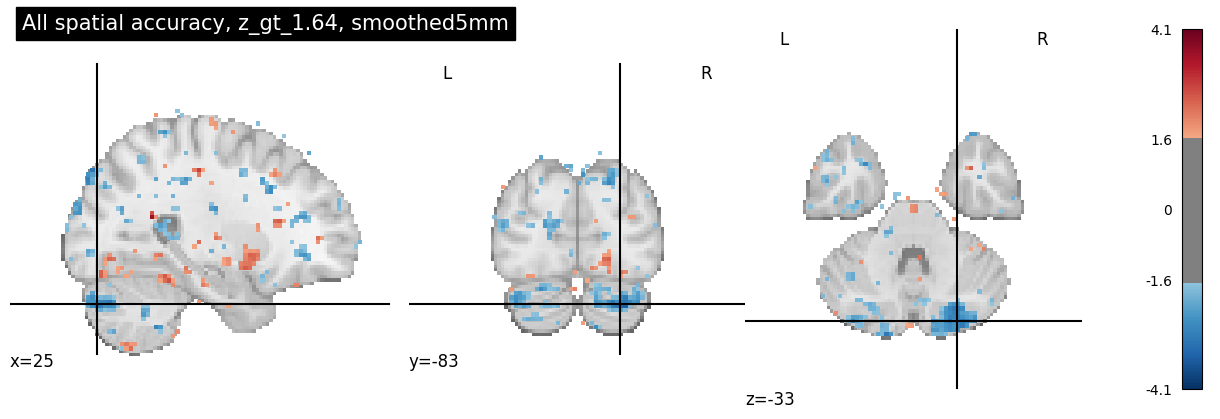

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_all_spatial_accuracy_positive_z_gt_1.64_from_smoothed5mm.png


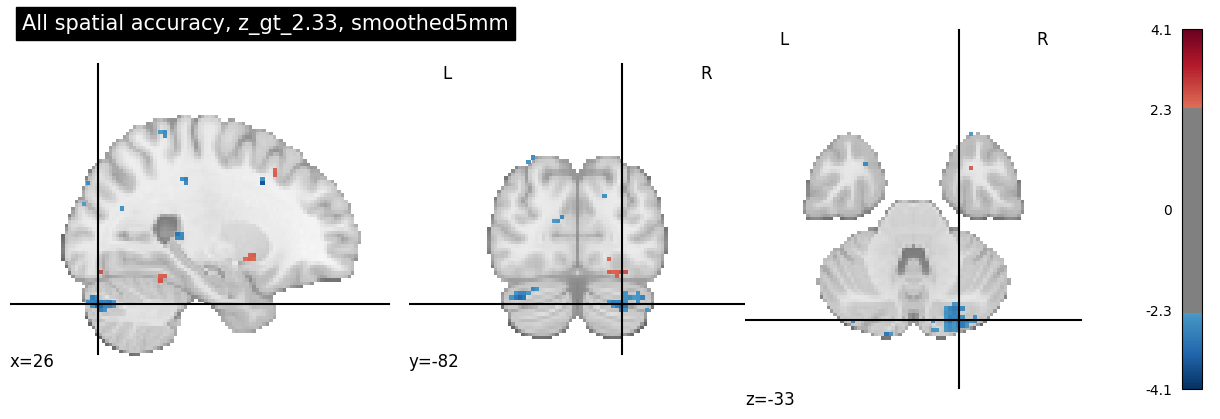

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_all_spatial_accuracy_positive_z_gt_2.33_from_smoothed5mm.png


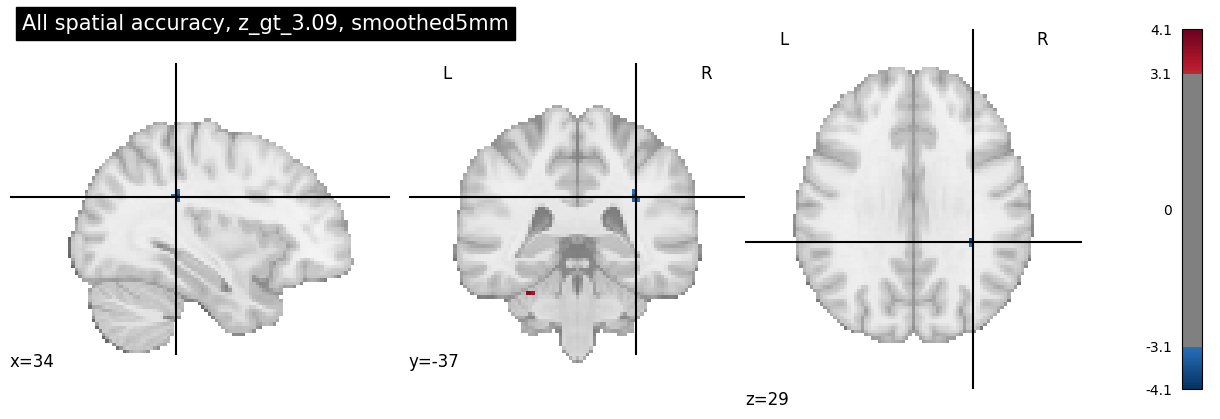

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_all_spatial_accuracy_positive_z_gt_3.09_from_smoothed5mm.png


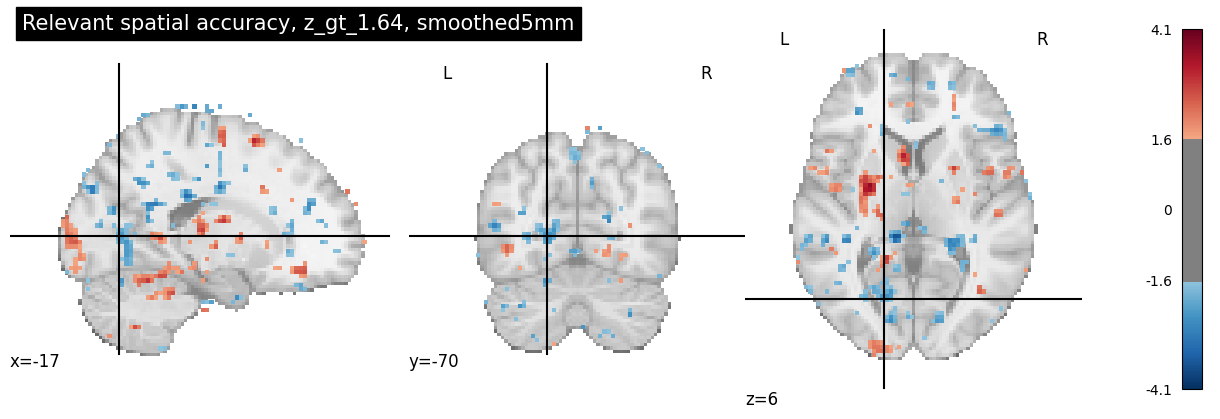

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_relevant_spatial_accuracy_positive_z_gt_1.64_from_smoothed5mm.png


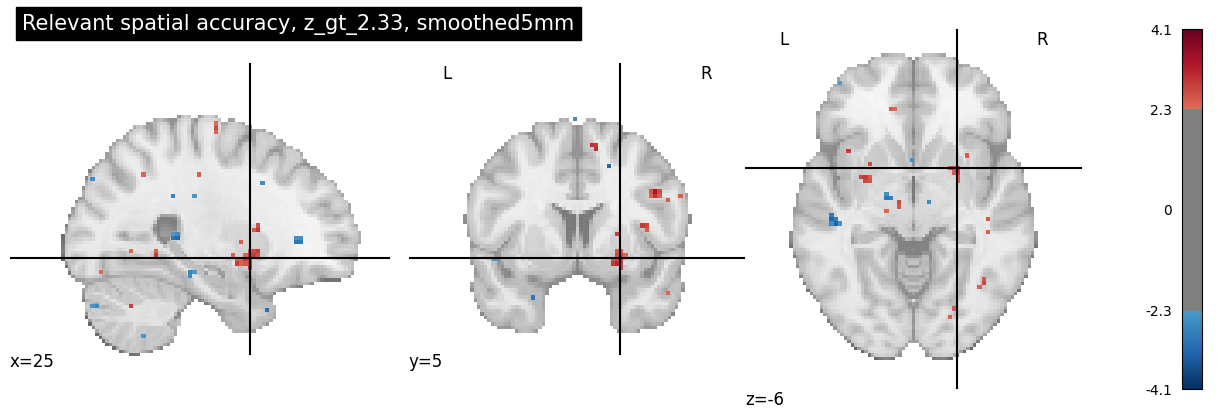

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_relevant_spatial_accuracy_positive_z_gt_2.33_from_smoothed5mm.png


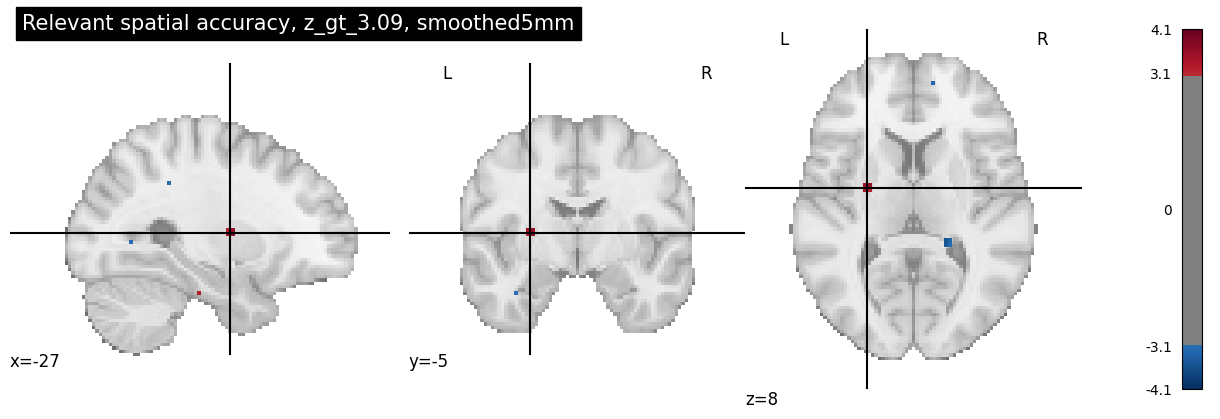

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_relevant_spatial_accuracy_positive_z_gt_3.09_from_smoothed5mm.png


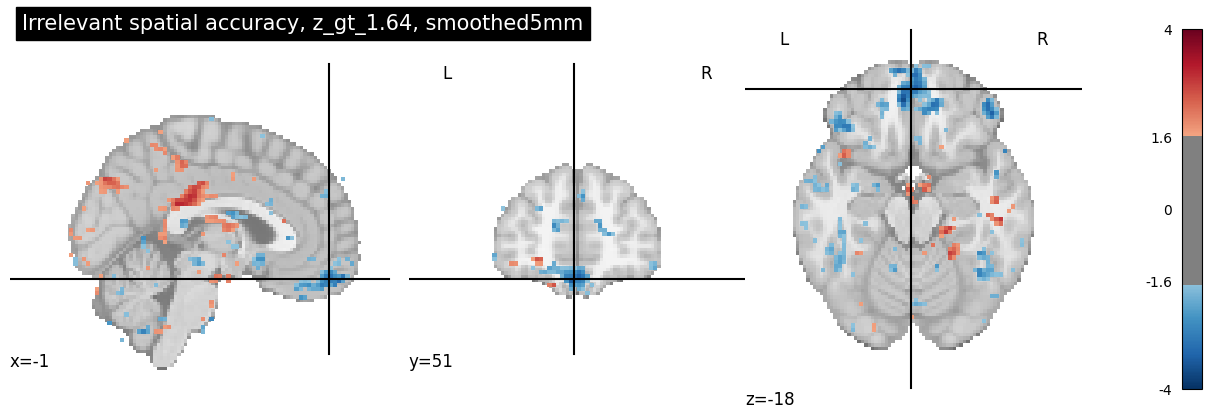

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_irrelevant_spatial_accuracy_positive_z_gt_1.64_from_smoothed5mm.png


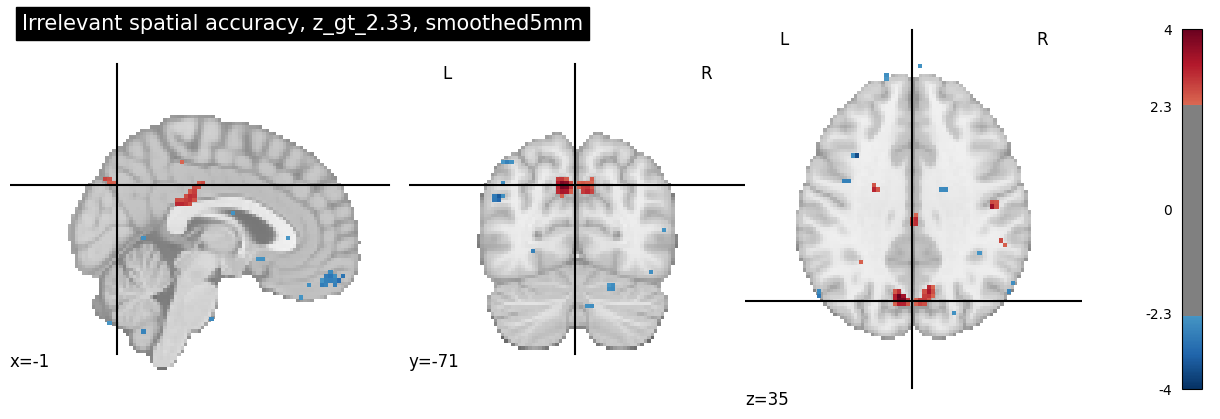

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_irrelevant_spatial_accuracy_positive_z_gt_2.33_from_smoothed5mm.png


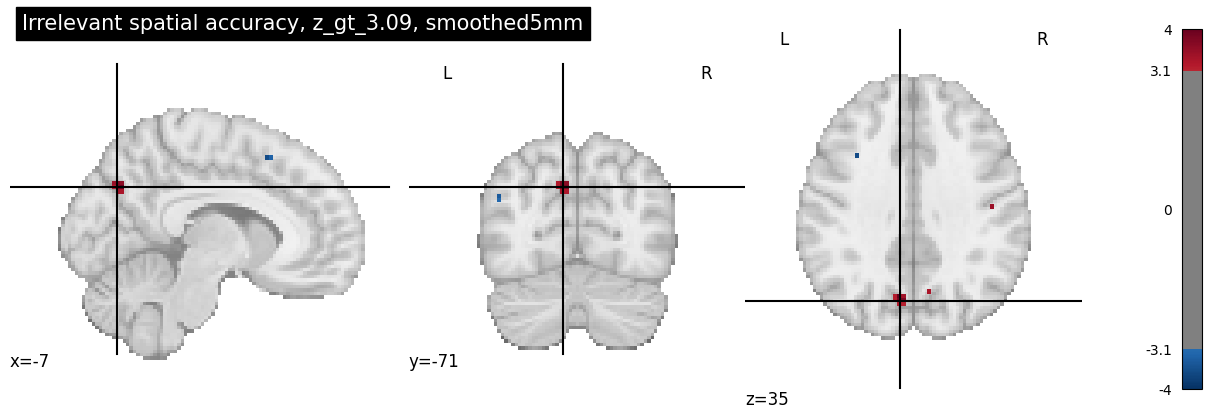

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_irrelevant_spatial_accuracy_positive_z_gt_3.09_from_smoothed5mm.png


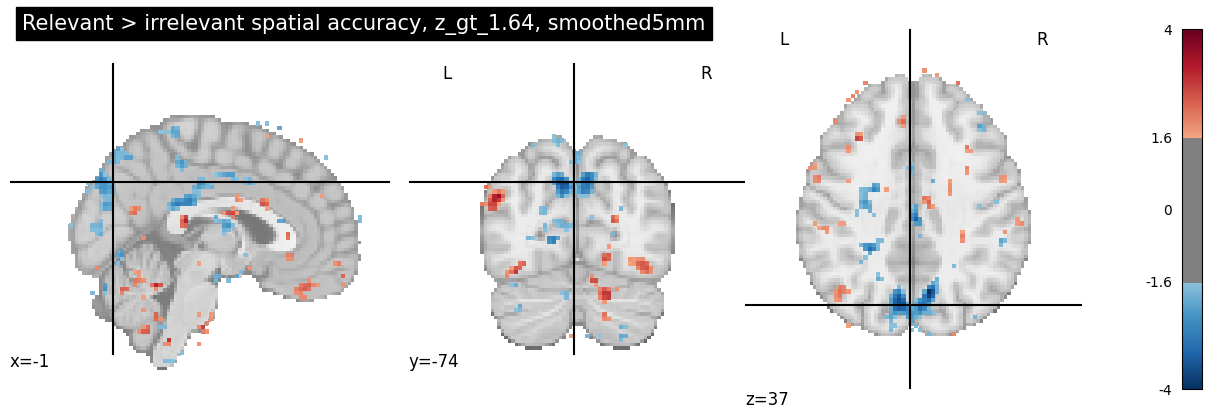

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_relevant_gt_irrelevant_spatial_accuracy_z_gt_1.64_from_smoothed5mm.png


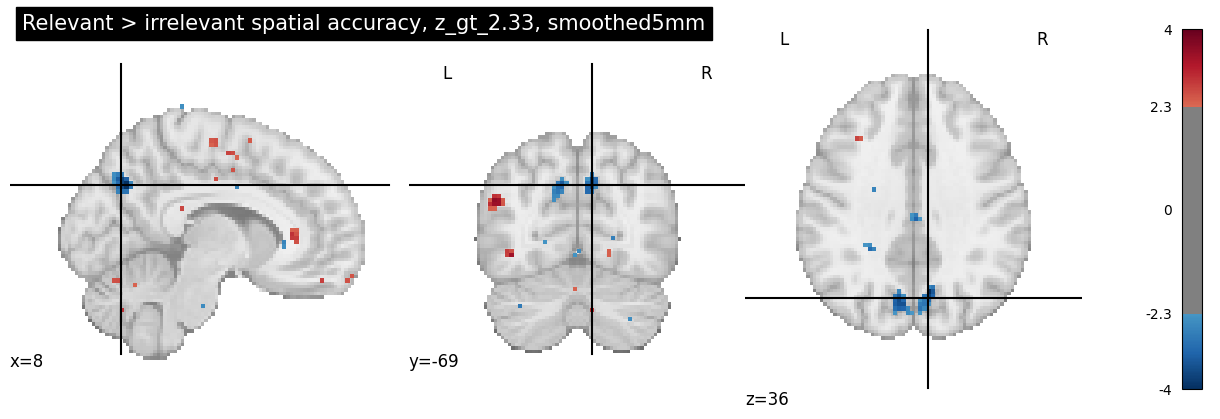

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_relevant_gt_irrelevant_spatial_accuracy_z_gt_2.33_from_smoothed5mm.png


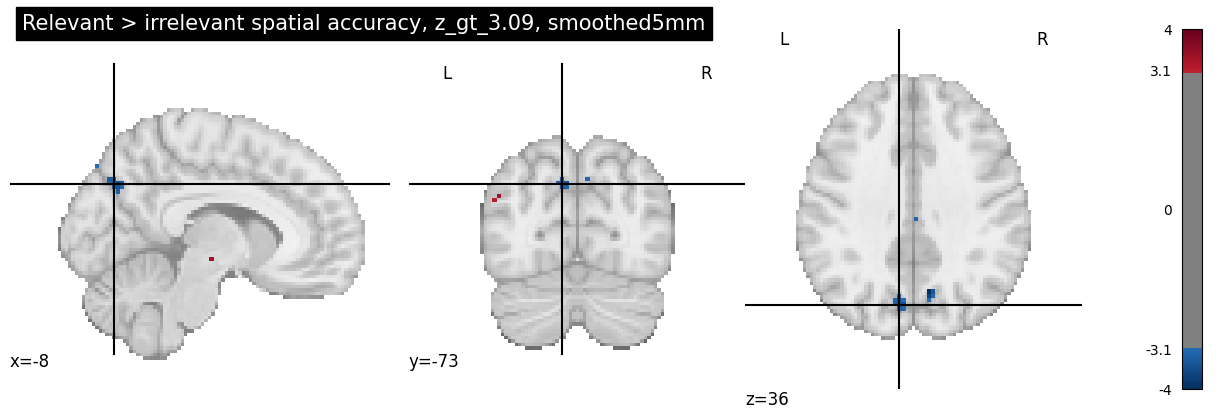

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/second_level_from_smoothed5mm/figures/group_primary_relevant_gt_irrelevant_spatial_accuracy_z_gt_3.09_from_smoothed5mm.png


In [16]:
# ============================================================
# 13. Plot group-level spatial-accuracy maps
# ============================================================

SPATIAL_CONTRAST_LABELS = {
    "all_spatial_accuracy_positive": "All spatial accuracy",
    "relevant_spatial_accuracy_positive": "Relevant spatial accuracy",
    "irrelevant_spatial_accuracy_positive": "Irrelevant spatial accuracy",
    "relevant_gt_irrelevant_spatial_accuracy": "Relevant > irrelevant spatial accuracy",
}

GROUP_THRESHOLDS = {
    "z_gt_1.64": 1.64,
    "z_gt_2.33": 2.33,
    "z_gt_3.09": 3.09,
}

for contrast_name, label in SPATIAL_CONTRAST_LABELS.items():
    z_path = get_group_spatial_z_map(contrast_name)
    assert z_path.exists(), f"Missing group z-map: {z_path}"
    
    z_img = load_img(str(z_path))
    
    for threshold_label, threshold in GROUP_THRESHOLDS.items():
        fig = plt.figure(figsize=(12, 4))
        
        plot_stat_map(
            z_img,
            threshold=threshold,
            display_mode="ortho",
            cut_coords=None,
            title=f"{label}, {threshold_label}, {SMOOTHING_LABEL}",
            figure=fig,
        )
        
        out_path = (
            SECOND_LEVEL_FIG_DIR
            / f"group_primary_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.png"
        )
        
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
        plt.show()
        
        print("Saved:", out_path)

In [17]:
# ============================================================
# 14. Threshold correction check for spatial-accuracy group maps
# ============================================================

from nilearn.glm import threshold_stats_img

threshold_rows = []

for contrast_name, label in SPATIAL_CONTRAST_LABELS.items():
    z_img = load_img(str(get_group_spatial_z_map(contrast_name)))
    
    checks = [
        {
            "threshold_name": "uncorrected_p001_one_sided",
            "height_control": "fpr",
            "alpha": 0.001,
        },
        {
            "threshold_name": "fdr_q05_one_sided",
            "height_control": "fdr",
            "alpha": 0.05,
        },
        {
            "threshold_name": "fdr_q10_one_sided",
            "height_control": "fdr",
            "alpha": 0.10,
        },
        {
            "threshold_name": "bonferroni_p05_one_sided",
            "height_control": "bonferroni",
            "alpha": 0.05,
        },
    ]
    
    for check in checks:
        thresholded_img, threshold = threshold_stats_img(
            z_img,
            alpha=check["alpha"],
            height_control=check["height_control"],
            cluster_threshold=0,
            two_sided=False,
        )
        
        data = thresholded_img.get_fdata()
        n_nonzero_voxels = int(np.sum(data != 0))
        max_z_after_threshold = float(np.nanmax(data)) if n_nonzero_voxels > 0 else np.nan
        
        out_path = (
            SECOND_LEVEL_MAPS_DIR
            / f"group_primary_{contrast_name}_{check['threshold_name']}_thresholded_from_{SMOOTHING_LABEL}.nii.gz"
        )
        thresholded_img.to_filename(out_path)
        
        threshold_rows.append({
            "contrast": contrast_name,
            "label": label,
            "threshold_name": check["threshold_name"],
            "height_control": check["height_control"],
            "alpha": check["alpha"],
            "z_threshold": threshold,
            "n_nonzero_voxels": n_nonzero_voxels,
            "max_z_after_threshold": max_z_after_threshold,
            "thresholded_map_path": str(out_path),
        })

threshold_summary = pd.DataFrame(threshold_rows)

display(threshold_summary)

threshold_summary_path = (
    CONTROL_TABLE_DIR
    / f"spatial_accuracy_group_threshold_correction_summary_from_{SMOOTHING_LABEL}.csv"
)

threshold_summary.to_csv(threshold_summary_path, index=False)

print("Saved:", threshold_summary_path)

/tmp/ipykernel_196014/2145532547.py:36: UserWarning: The given float value must not exceed 3.690713882446289. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_196014/2145532547.py:36: UserWarning: The given float value must not exceed 3.690713882446289. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_196014/2145532547.py:36: UserWarning: The given float value must not exceed 3.690713882446289. But, you have given threshold=4.944055204816593.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_196014/2145532547.py:36: UserWarning: The given float value must not exceed 4.104663848876953. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_196014/2145532547.py:36: UserWarning: The given float value must not exceed 4.104663848876953. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/

,contrast,label,threshold_name,height_control,alpha,z_threshold,n_nonzero_voxels,max_z_after_threshold,thresholded_map_path
0,all_spatial_accuracy_positive,All spatial accuracy,uncorrected_p001_one_sided,fpr,0.001,3.090232,17,3.690714,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,all_spatial_accuracy_positive,All spatial accuracy,fdr_q05_one_sided,fdr,0.050,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,all_spatial_accuracy_positive,All spatial accuracy,fdr_q10_one_sided,fdr,0.100,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,all_spatial_accuracy_positive,All spatial accuracy,bonferroni_p05_one_sided,bonferroni,0.050,4.944055,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,relevant_spatial_accuracy_positive,Relevant spatial accuracy,uncorrected_p001_one_sided,fpr,0.001,3.090232,39,4.104664,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
5,relevant_spatial_accuracy_positive,Relevant spatial accuracy,fdr_q05_one_sided,fdr,0.050,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
6,relevant_spatial_accuracy_positive,Relevant spatial accuracy,fdr_q10_one_sided,fdr,0.100,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
7,relevant_spatial_accuracy_positive,Relevant spatial accuracy,bonferroni_p05_one_sided,bonferroni,0.050,4.944055,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
8,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,uncorrected_p001_one_sided,fpr,0.001,3.090232,39,4.037138,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
9,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,fdr_q05_one_sided,fdr,0.050,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/spatial_accuracy_group_threshold_correction_summary_from_smoothed5mm.csv


In [18]:
# ============================================================
# 15. Cluster tables for spatial-accuracy group maps
# ============================================================

from nilearn.reporting import get_clusters_table

cluster_rows = []

# Same minimum as before: 10 voxels worth of volume.
reference_img = load_img(str(get_group_spatial_z_map("all_spatial_accuracy_positive")))
voxel_volume_mm3 = abs(np.linalg.det(reference_img.affine[:3, :3]))
min_cluster_size_voxels = 10
min_cluster_size_mm3 = min_cluster_size_voxels * voxel_volume_mm3

print("Voxel volume mm3:", voxel_volume_mm3)
print("Minimum cluster size mm3:", min_cluster_size_mm3)

for contrast_name, label in SPATIAL_CONTRAST_LABELS.items():
    z_img = load_img(str(get_group_spatial_z_map(contrast_name)))
    
    for threshold_label, threshold in GROUP_THRESHOLDS.items():
        try:
            table = get_clusters_table(
                z_img,
                stat_threshold=threshold,
                cluster_threshold=0,
                two_sided=False,
            )
            
            if table is None or len(table) == 0:
                cluster_rows.append({
                    "contrast": contrast_name,
                    "label": label,
                    "threshold_label": threshold_label,
                    "z_threshold": threshold,
                    "n_parent_clusters": 0,
                    "max_peak_stat": np.nan,
                    "largest_cluster_mm3": np.nan,
                    "table_path": "",
                })
                continue
            
            table = table.copy()
            
            # Keep only parent clusters, not subpeaks.
            parent_table = table.loc[
                ~table["Cluster ID"].astype(str).str.contains("[a-zA-Z]", regex=True)
            ].copy()
            
            parent_table["Cluster Size (mm3)"] = pd.to_numeric(
                parent_table["Cluster Size (mm3)"],
                errors="coerce",
            )
            
            parent_table = parent_table.loc[
                parent_table["Cluster Size (mm3)"] >= min_cluster_size_mm3
            ].copy()
            
            table_path = (
                CONTROL_TABLE_DIR
                / f"clusters_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.csv"
            )
            parent_table.to_csv(table_path, index=False)
            
            if len(parent_table) == 0:
                n_clusters = 0
                max_peak = np.nan
                largest_cluster = np.nan
            else:
                n_clusters = len(parent_table)
                max_peak = parent_table["Peak Stat"].max()
                largest_cluster = parent_table["Cluster Size (mm3)"].max()
            
            cluster_rows.append({
                "contrast": contrast_name,
                "label": label,
                "threshold_label": threshold_label,
                "z_threshold": threshold,
                "n_parent_clusters": n_clusters,
                "max_peak_stat": max_peak,
                "largest_cluster_mm3": largest_cluster,
                "table_path": str(table_path),
            })
        
        except Exception as e:
            cluster_rows.append({
                "contrast": contrast_name,
                "label": label,
                "threshold_label": threshold_label,
                "z_threshold": threshold,
                "n_parent_clusters": np.nan,
                "max_peak_stat": np.nan,
                "largest_cluster_mm3": np.nan,
                "table_path": "",
                "error": repr(e),
            })

cluster_summary = pd.DataFrame(cluster_rows)

display(cluster_summary)

cluster_summary_path = (
    CONTROL_TABLE_DIR
    / f"spatial_accuracy_group_cluster_summary_from_{SMOOTHING_LABEL}.csv"
)

cluster_summary.to_csv(cluster_summary_path, index=False)

print("Saved:", cluster_summary_path)

Voxel volume mm3: 15.625000000000002
Minimum cluster size mm3: 156.25000000000003


,contrast,label,threshold_label,z_threshold,n_parent_clusters,max_peak_stat,largest_cluster_mm3,table_path
0,all_spatial_accuracy_positive,All spatial accuracy,z_gt_1.64,1.64,49,3.690714,1921.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,all_spatial_accuracy_positive,All spatial accuracy,z_gt_2.33,2.33,4,3.623700,234.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,all_spatial_accuracy_positive,All spatial accuracy,z_gt_3.09,3.09,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,relevant_spatial_accuracy_positive,Relevant spatial accuracy,z_gt_1.64,1.64,81,4.104664,4796.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,relevant_spatial_accuracy_positive,Relevant spatial accuracy,z_gt_2.33,2.33,10,4.104664,531.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
5,relevant_spatial_accuracy_positive,Relevant spatial accuracy,z_gt_3.09,3.09,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
6,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,z_gt_1.64,1.64,46,4.037138,5000.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
7,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,z_gt_2.33,2.33,6,4.037138,1687.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
8,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,z_gt_3.09,3.09,1,4.037138,281.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
9,relevant_gt_irrelevant_spatial_accuracy,Relevant > irrelevant spatial accuracy,z_gt_1.64,1.64,124,3.983776,5375.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/spatial_accuracy_group_cluster_summary_from_smoothed5mm.csv


In [19]:
# ============================================================
# 16. Inspect top spatial-accuracy cluster tables
# ============================================================

cluster_tables_to_inspect = []

for contrast_name, label in SPATIAL_CONTRAST_LABELS.items():
    for threshold_label in ["z_gt_2.33", "z_gt_3.09"]:
        table_path = (
            CONTROL_TABLE_DIR
            / f"clusters_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.csv"
        )
        
        if table_path.exists():
            table = pd.read_csv(table_path)
            if len(table) > 0:
                table = table.copy()
                table["contrast"] = contrast_name
                table["label"] = label
                table["threshold_label"] = threshold_label
                cluster_tables_to_inspect.append(table)

if len(cluster_tables_to_inspect) > 0:
    spatial_cluster_details = pd.concat(cluster_tables_to_inspect, ignore_index=True)
    
    cols_to_show = [
        "contrast",
        "label",
        "threshold_label",
        "Cluster ID",
        "X",
        "Y",
        "Z",
        "Peak Stat",
        "Cluster Size (mm3)",
    ]
    
    existing_cols = [col for col in cols_to_show if col in spatial_cluster_details.columns]
    
    spatial_cluster_details = spatial_cluster_details.sort_values(
        ["contrast", "threshold_label", "Peak Stat"],
        ascending=[True, True, False],
    )
    
    display(spatial_cluster_details[existing_cols])
    
    out_path = (
        CONTROL_TABLE_DIR
        / f"spatial_accuracy_cluster_details_z233_z309_from_{SMOOTHING_LABEL}.csv"
    )
    spatial_cluster_details.to_csv(out_path, index=False)
    print("Saved:", out_path)

else:
    print("No cluster tables with surviving clusters at z > 2.33 or z > 3.09.")

,contrast,label,threshold_label,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,all_spatial_accuracy_positive,All spatial accuracy,z_gt_2.33,2,6.5,18.0,17.0,3.623700,171
1,all_spatial_accuracy_positive,All spatial accuracy,z_gt_2.33,6,-28.5,0.5,7.0,3.340826,218
2,all_spatial_accuracy_positive,All spatial accuracy,z_gt_2.33,12,-16.0,-39.5,-15.5,3.065110,187
3,all_spatial_accuracy_positive,All spatial accuracy,z_gt_2.33,14,14.0,-19.5,14.5,3.016017,234
14,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,z_gt_2.33,1,-8.5,-69.5,34.5,4.037138,1687
15,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,z_gt_2.33,2,19.0,-32.0,-15.5,3.954708,296
16,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,z_gt_2.33,3,16.5,-34.5,-5.5,3.890925,203
17,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,z_gt_2.33,4,21.5,-24.5,2.0,3.594152,203
18,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,z_gt_2.33,5,1.5,-29.5,29.5,3.476853,1140
19,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,z_gt_2.33,23,-8.5,-92.0,2.0,2.787584,218


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/spatial_accuracy_cluster_details_z233_z309_from_smoothed5mm.csv


In [22]:
# ============================================================
# 20. Subject-specific hippoAmyg ROI setup
# Spatial-accuracy-only control GLM
# ============================================================

from nilearn.image import resample_to_img
from nilearn.masking import apply_mask
from scipy import stats

SUPERVISOR_MASK_ROOT = DATA_DIR / "rois" / "hippoAmyg_02022024"

ROI_DIR = CONTROL_OUT_DIR / "roi"
ROI_TABLE_DIR = ROI_DIR / "tables"
ROI_FIG_DIR = ROI_DIR / "figures"

for path in [
    ROI_DIR,
    ROI_TABLE_DIR,
    ROI_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Supervisor mask root:")
print(SUPERVISOR_MASK_ROOT)
print("exists:", SUPERVISOR_MASK_ROOT.exists())

assert SUPERVISOR_MASK_ROOT.exists(), f"Missing: {SUPERVISOR_MASK_ROOT}"


def get_supervisor_hippoamyg_mask(subject, hemi, space="MNI152NLin2009cAsym"):
    return (
        SUPERVISOR_MASK_ROOT
        / subject
        / "ses-01"
        / "anat"
        / f"{subject}_ses-01_space-{space}_hemi-{hemi}_label-hippoAmyg.nii.gz"
    )


def get_spatial_accuracy_first_level_effect_map(subject, contrast_name):
    return (
        FIRST_LEVEL_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
    )


# Check mask and effect-map availability.
availability_rows = []

for subject in primary_subjects_final:
    row = {
        "subject": subject,
        "left_mask_exists": get_supervisor_hippoamyg_mask(subject, "L").exists(),
        "right_mask_exists": get_supervisor_hippoamyg_mask(subject, "R").exists(),
    }
    
    for contrast_name in SPATIAL_ACCURACY_CONTRASTS.keys():
        row[f"{contrast_name}_effect_exists"] = get_spatial_accuracy_first_level_effect_map(
            subject,
            contrast_name,
        ).exists()
    
    availability_rows.append(row)

roi_availability = pd.DataFrame(availability_rows)

display(roi_availability)

assert roi_availability["left_mask_exists"].all(), "Some left masks are missing."
assert roi_availability["right_mask_exists"].all(), "Some right masks are missing."

for contrast_name in SPATIAL_ACCURACY_CONTRASTS.keys():
    assert roi_availability[f"{contrast_name}_effect_exists"].all(), (
        f"Some effect maps are missing for {contrast_name}"
    )

availability_path = ROI_TABLE_DIR / f"spatial_accuracy_supervisor_hippoamyg_availability_{SMOOTHING_LABEL}.csv"
roi_availability.to_csv(availability_path, index=False)

print("Saved:", availability_path)

Supervisor mask root:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024
exists: True


,subject,left_mask_exists,right_mask_exists,all_spatial_accuracy_positive_effect_exists,relevant_spatial_accuracy_positive_effect_exists,irrelevant_spatial_accuracy_positive_effect_exists,relevant_gt_irrelevant_spatial_accuracy_effect_exists
0,sub-P10,True,True,True,True,True,True
1,sub-P12,True,True,True,True,True,True
2,sub-P13,True,True,True,True,True,True
3,sub-P14,True,True,True,True,True,True
4,sub-P15,True,True,True,True,True,True
5,sub-P16,True,True,True,True,True,True
6,sub-P17,True,True,True,True,True,True
7,sub-P18,True,True,True,True,True,True
8,sub-P19,True,True,True,True,True,True
9,sub-P21,True,True,True,True,True,True


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/roi/tables/spatial_accuracy_supervisor_hippoamyg_availability_smoothed5mm.csv


In [23]:
# ============================================================
# 21. Extract spatial-accuracy effects from supervisor hippoAmyg masks
# ============================================================

def make_binary_resampled_mask(mask_path, reference_img):
    """
    Load supervisor label-valued hippoAmyg mask, binarize > 0,
    and resample to first-level effect-map grid.
    """
    mask_img = nib.load(str(mask_path))
    mask_data = mask_img.get_fdata()
    
    binary_mask_img = nib.Nifti1Image(
        (mask_data > 0).astype(np.uint8),
        affine=mask_img.affine,
        header=mask_img.header,
    )
    
    resampled_mask = resample_to_img(
        binary_mask_img,
        reference_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    resampled_data = resampled_mask.get_fdata() > 0
    
    resampled_binary_mask = nib.Nifti1Image(
        resampled_data.astype(np.uint8),
        affine=reference_img.affine,
        header=reference_img.header,
    )
    
    return resampled_binary_mask


def extract_mean_effect_from_mask(effect_img, mask_img):
    values = apply_mask(effect_img, mask_img)
    values = np.asarray(values).ravel()
    values = values[np.isfinite(values)]
    
    if len(values) == 0:
        return np.nan, 0
    
    return float(np.mean(values)), int(len(values))


roi_rows = []

for subject in primary_subjects_final:
    print("Extracting:", subject)
    
    # Use one contrast effect map as reference grid.
    reference_effect_path = get_spatial_accuracy_first_level_effect_map(
        subject,
        "all_spatial_accuracy_positive",
    )
    reference_img = nib.load(str(reference_effect_path))
    
    left_mask = make_binary_resampled_mask(
        get_supervisor_hippoamyg_mask(subject, "L"),
        reference_img,
    )
    right_mask = make_binary_resampled_mask(
        get_supervisor_hippoamyg_mask(subject, "R"),
        reference_img,
    )
    
    # Bilateral mask.
    bilateral_data = (
        (left_mask.get_fdata() > 0)
        | (right_mask.get_fdata() > 0)
    )
    
    bilateral_mask = nib.Nifti1Image(
        bilateral_data.astype(np.uint8),
        affine=reference_img.affine,
        header=reference_img.header,
    )
    
    masks = {
        "left_hippoAmyg": left_mask,
        "right_hippoAmyg": right_mask,
        "bilateral_hippoAmyg": bilateral_mask,
    }
    
    for contrast_name in SPATIAL_ACCURACY_CONTRASTS.keys():
        effect_path = get_spatial_accuracy_first_level_effect_map(subject, contrast_name)
        effect_img = nib.load(str(effect_path))
        
        for roi_name, mask_img in masks.items():
            mean_effect, n_voxels = extract_mean_effect_from_mask(effect_img, mask_img)
            
            roi_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "roi": roi_name,
                "mean_effect": mean_effect,
                "n_voxels": n_voxels,
                "effect_map_path": str(effect_path),
            })

spatial_accuracy_roi_effects = pd.DataFrame(roi_rows)

display(spatial_accuracy_roi_effects.head())

print("\nVoxel count summary:")
display(
    spatial_accuracy_roi_effects
    .groupby("roi")
    .agg(
        mean_n_voxels=("n_voxels", "mean"),
        min_n_voxels=("n_voxels", "min"),
        max_n_voxels=("n_voxels", "max"),
    )
    .reset_index()
)

roi_effects_path = ROI_TABLE_DIR / f"spatial_accuracy_supervisor_hippoamyg_subject_effects_{SMOOTHING_LABEL}.csv"
spatial_accuracy_roi_effects.to_csv(roi_effects_path, index=False)

print("Saved:", roi_effects_path)

Extracting: sub-P10
Extracting: sub-P12
Extracting: sub-P13
Extracting: sub-P14
Extracting: sub-P15
Extracting: sub-P16
Extracting: sub-P17
Extracting: sub-P18
Extracting: sub-P19
Extracting: sub-P21
Extracting: sub-P22
Extracting: sub-P23
Extracting: sub-P25
Extracting: sub-P27
Extracting: sub-P31
Extracting: sub-P34
Extracting: sub-P35
Extracting: sub-P36
Extracting: sub-P37
Extracting: sub-P41
Extracting: sub-P42
Extracting: sub-P43
Extracting: sub-P44
Extracting: sub-P45
Extracting: sub-P47
Extracting: sub-P48
Extracting: sub-P50
Extracting: sub-P51


,subject,contrast,roi,mean_effect,n_voxels,effect_map_path
0,sub-P10,all_spatial_accuracy_positive,left_hippoAmyg,-0.001267,448,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P10,all_spatial_accuracy_positive,right_hippoAmyg,0.017308,451,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P10,all_spatial_accuracy_positive,bilateral_hippoAmyg,0.008051,899,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P10,relevant_spatial_accuracy_positive,left_hippoAmyg,0.001157,448,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P10,relevant_spatial_accuracy_positive,right_hippoAmyg,0.013350,451,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Voxel count summary:


,roi,mean_n_voxels,min_n_voxels,max_n_voxels
0,bilateral_hippoAmyg,932.428571,859,1020
1,left_hippoAmyg,455.785714,411,494
2,right_hippoAmyg,476.642857,446,526


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/roi/tables/spatial_accuracy_supervisor_hippoamyg_subject_effects_smoothed5mm.csv


In [24]:
# ============================================================
# 22. Group-level ROI statistics for spatial-accuracy hippoAmyg effects
# ============================================================

roi_summary_rows = []

for (contrast_name, roi_name), df in spatial_accuracy_roi_effects.groupby(["contrast", "roi"]):
    values = df["mean_effect"].dropna().values
    n = len(values)
    
    mean_effect = float(np.mean(values))
    sd_effect = float(np.std(values, ddof=1))
    sem_effect = float(sd_effect / np.sqrt(n))
    
    t_stat, p_two_sided = stats.ttest_1samp(values, popmean=0.0)
    
    # One-sided positive p-value.
    if t_stat >= 0:
        p_one_sided_positive = p_two_sided / 2
    else:
        p_one_sided_positive = 1 - (p_two_sided / 2)
    
    n_positive = int(np.sum(values > 0))
    
    roi_summary_rows.append({
        "contrast": contrast_name,
        "roi": roi_name,
        "n_subjects": n,
        "mean_effect": mean_effect,
        "sd_effect": sd_effect,
        "sem_effect": sem_effect,
        "t_stat": float(t_stat),
        "p_two_sided": float(p_two_sided),
        "p_one_sided_positive": float(p_one_sided_positive),
        "n_positive": n_positive,
        "proportion_positive": n_positive / n,
    })

spatial_accuracy_roi_summary = pd.DataFrame(roi_summary_rows)

# Add readable labels and priority.
spatial_accuracy_roi_summary["contrast_label"] = spatial_accuracy_roi_summary["contrast"].map(
    SPATIAL_CONTRAST_LABELS
)

spatial_accuracy_roi_summary["priority"] = spatial_accuracy_roi_summary["contrast"].map(
    contrast_priority
)

spatial_accuracy_roi_summary = spatial_accuracy_roi_summary[
    [
        "contrast",
        "contrast_label",
        "priority",
        "roi",
        "n_subjects",
        "mean_effect",
        "sd_effect",
        "sem_effect",
        "t_stat",
        "p_two_sided",
        "p_one_sided_positive",
        "n_positive",
        "proportion_positive",
    ]
].sort_values(["priority", "contrast", "roi"])

display(spatial_accuracy_roi_summary)

roi_summary_path = ROI_TABLE_DIR / f"spatial_accuracy_supervisor_hippoamyg_group_summary_{SMOOTHING_LABEL}.csv"
spatial_accuracy_roi_summary.to_csv(roi_summary_path, index=False)

print("Saved:", roi_summary_path)

,contrast,contrast_label,priority,roi,n_subjects,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive
0,all_spatial_accuracy_positive,All spatial accuracy,primary,bilateral_hippoAmyg,28,0.001689,0.040683,0.007688,0.219743,0.827724,0.413862,17,0.607143
1,all_spatial_accuracy_positive,All spatial accuracy,primary,left_hippoAmyg,28,0.000949,0.043139,0.008152,0.116417,0.908184,0.454092,16,0.571429
2,all_spatial_accuracy_positive,All spatial accuracy,primary,right_hippoAmyg,28,0.002381,0.041775,0.007895,0.301543,0.765311,0.382655,17,0.607143
3,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,secondary_condition_specific,bilateral_hippoAmyg,28,0.002550,0.061881,0.011694,0.218045,0.829033,0.414517,15,0.535714
4,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,secondary_condition_specific,left_hippoAmyg,28,-0.000610,0.063879,0.012072,-0.050512,0.960087,0.519957,15,0.535714
5,irrelevant_spatial_accuracy_positive,Irrelevant spatial accuracy,secondary_condition_specific,right_hippoAmyg,28,0.005509,0.065847,0.012444,0.442711,0.661501,0.330751,14,0.500000
9,relevant_spatial_accuracy_positive,Relevant spatial accuracy,secondary_condition_specific,bilateral_hippoAmyg,28,0.000829,0.038184,0.007216,0.114888,0.909384,0.454692,17,0.607143
10,relevant_spatial_accuracy_positive,Relevant spatial accuracy,secondary_condition_specific,left_hippoAmyg,28,0.002508,0.044359,0.008383,0.299168,0.767103,0.383551,15,0.535714
11,relevant_spatial_accuracy_positive,Relevant spatial accuracy,secondary_condition_specific,right_hippoAmyg,28,-0.000748,0.036674,0.006931,-0.107893,0.914879,0.542561,14,0.500000
6,relevant_gt_irrelevant_spatial_accuracy,Relevant > irrelevant spatial accuracy,secondary_interaction,bilateral_hippoAmyg,28,-0.001721,0.062881,0.011883,-0.144813,0.885934,0.557033,14,0.500000


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/roi/tables/spatial_accuracy_supervisor_hippoamyg_group_summary_smoothed5mm.csv


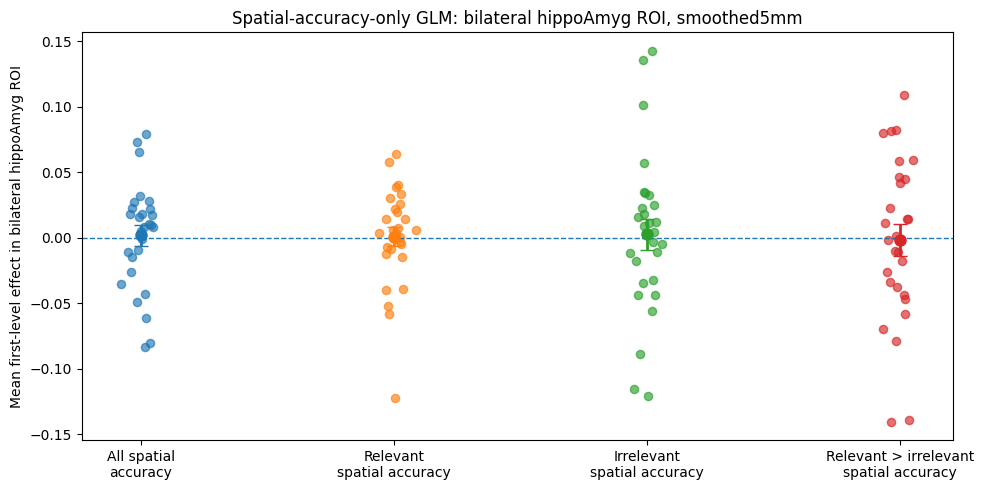

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/roi/figures/spatial_accuracy_bilateral_hippoAmyg_effects_smoothed5mm.png


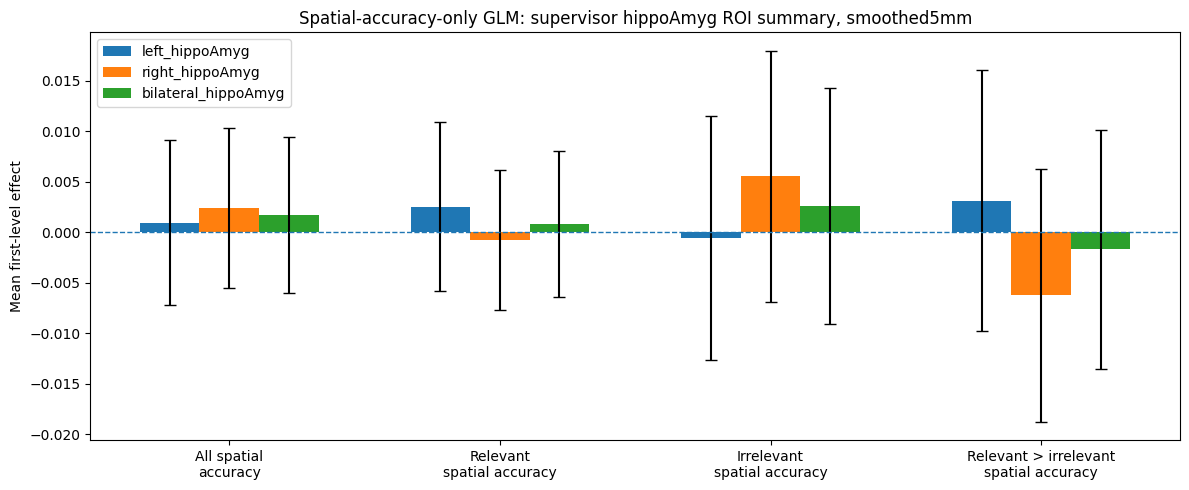

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/roi/figures/spatial_accuracy_hippoAmyg_left_right_bilateral_summary_smoothed5mm.png


In [25]:
# ============================================================
# 23. Plot spatial-accuracy hippoAmyg ROI effects
# ============================================================

plot_df = spatial_accuracy_roi_effects.merge(
    spatial_accuracy_roi_summary[
        ["contrast", "roi", "contrast_label", "priority", "mean_effect", "sem_effect"]
    ],
    on=["contrast", "roi"],
    suffixes=("", "_group"),
)

# Focus first on bilateral ROI, which is the clean primary ROI summary.
bilateral_df = spatial_accuracy_roi_effects.loc[
    spatial_accuracy_roi_effects["roi"] == "bilateral_hippoAmyg"
].copy()

contrast_order = [
    "all_spatial_accuracy_positive",
    "relevant_spatial_accuracy_positive",
    "irrelevant_spatial_accuracy_positive",
    "relevant_gt_irrelevant_spatial_accuracy",
]

contrast_labels_short = {
    "all_spatial_accuracy_positive": "All spatial\naccuracy",
    "relevant_spatial_accuracy_positive": "Relevant\nspatial accuracy",
    "irrelevant_spatial_accuracy_positive": "Irrelevant\nspatial accuracy",
    "relevant_gt_irrelevant_spatial_accuracy": "Relevant > irrelevant\nspatial accuracy",
}

fig, ax = plt.subplots(figsize=(10, 5))

x_positions = np.arange(len(contrast_order))
rng = np.random.default_rng(42)

for i, contrast_name in enumerate(contrast_order):
    values = bilateral_df.loc[
        bilateral_df["contrast"] == contrast_name,
        "mean_effect",
    ].values
    
    jitter = rng.normal(loc=0, scale=0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), x_positions[i]) + jitter,
        values,
        alpha=0.65,
        s=35,
    )
    
    ax.errorbar(
        x_positions[i],
        np.mean(values),
        yerr=np.std(values, ddof=1) / np.sqrt(len(values)),
        marker="o",
        markersize=8,
        capsize=5,
        linewidth=2,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels([contrast_labels_short[c] for c in contrast_order])
ax.set_ylabel("Mean first-level effect in bilateral hippoAmyg ROI")
ax.set_title(f"Spatial-accuracy-only GLM: bilateral hippoAmyg ROI, {SMOOTHING_LABEL}")
plt.tight_layout()

out_path = ROI_FIG_DIR / f"spatial_accuracy_bilateral_hippoAmyg_effects_{SMOOTHING_LABEL}.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# Optional: left/right/bilateral summary bar-style plot.
summary_plot_df = spatial_accuracy_roi_summary.copy()

fig, ax = plt.subplots(figsize=(12, 5))

roi_order = ["left_hippoAmyg", "right_hippoAmyg", "bilateral_hippoAmyg"]
width = 0.22
x_positions = np.arange(len(contrast_order))

for j, roi_name in enumerate(roi_order):
    means = []
    sems = []
    
    for contrast_name in contrast_order:
        row = summary_plot_df.loc[
            (summary_plot_df["contrast"] == contrast_name)
            & (summary_plot_df["roi"] == roi_name)
        ].iloc[0]
        
        means.append(row["mean_effect"])
        sems.append(row["sem_effect"])
    
    ax.bar(
        x_positions + (j - 1) * width,
        means,
        width=width,
        yerr=sems,
        capsize=4,
        label=roi_name,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels([contrast_labels_short[c] for c in contrast_order])
ax.set_ylabel("Mean first-level effect")
ax.set_title(f"Spatial-accuracy-only GLM: supervisor hippoAmyg ROI summary, {SMOOTHING_LABEL}")
ax.legend()
plt.tight_layout()

out_path = ROI_FIG_DIR / f"spatial_accuracy_hippoAmyg_left_right_bilateral_summary_{SMOOTHING_LABEL}.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)